In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
import cftime
import os
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from fastjmd95 import jmd95numba

In [2]:
# ============== LOAD LLC ==============
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

# ============== LOAD EMULATORS ==============
emulator_configs = [
    {
        'name': 'exp3_ckpt38',
        'key': 'emulator_1',
        'path': '/orcd/data/abodner/002/cody/inference_patch/2026-05-29-eval:Samudra_LLC:long_curriculum_strides=3_ckpt-38-7days-14748021/predictions_4d.zarr',
        'desc': ''   
    },
    {
        'name': 'A_ckpt38',
        'key': 'emulator_2',
        'path': '/orcd/data/abodner/002/cody/inference_patch/2026-06-08-eval:Samudra_LLC:A_ckpt-38-15626896/predictions_4d.zarr',
        'desc': ''
    },
        {
        'name': 'B_ckpt38',
        'key': 'emulator_3',
        'path': '/orcd/data/abodner/002/cody/inference_patch/2026-06-08-eval:Samudra_LLC:B_ckpt-38-15632827/predictions_4d.zarr',
        'desc': ''
    },
]

# ============== OPEN EMULATOR DATASETS ==============
emulator_patches_raw = {}
for cfg in emulator_configs:
    emulator_patches_raw[cfg['key']] = xr.open_dataset(cfg['path'], consolidated=True)
    print(f"Loaded {cfg['name']}: {cfg['desc']}")

# ============== TIME MATCHING ==============
def normalize_times(times):
    return pd.DatetimeIndex([
        pd.Timestamp(
            int(t.year), int(t.month), int(t.day),
            int(t.hour), int(t.minute), int(t.second)
        )
        if hasattr(t, "year")
        else pd.Timestamp(t).floor("s")
        for t in times
    ])

llc_times_norm = normalize_times(llc_patch_full.time.values)

common_times = llc_times_norm
for cfg in emulator_configs:
    emulator_times_norm = normalize_times(emulator_patches_raw[cfg['key']].time.values)
    common_times = common_times.intersection(emulator_times_norm)

common_times = common_times.sort_values()

llc_mask = llc_times_norm.isin(common_times)
llc_patch = llc_patch_full.isel(time=llc_mask)

print(f"LLC subset to {len(common_times)} common times")

# ============== PORT GRID VARS & BUILD UNIFIED STRUCTURE ==============
grid_vars = ['XC', 'YC', 'rA', 'Z']

emulator_patches = {}
for cfg in emulator_configs:
    patch_raw = emulator_patches_raw[cfg['key']]
    patch_times_norm = normalize_times(patch_raw.time.values)

    patch_mask = patch_times_norm.isin(common_times)
    patch = patch_raw.isel(time=patch_mask)

    for gv in grid_vars:
        patch[gv] = llc_patch[gv]

    emulator_patches[cfg['key']] = patch

# ============== UNIFIED REFERENCE LISTS ==============
emulator_info = [(cfg['name'], cfg['key']) for cfg in emulator_configs]
n_emulators = len(emulator_info)

all_patches = {'llc': llc_patch}
all_patches.update(emulator_patches)

print(f"\n=== Setup complete: LLC + {n_emulators} emulators ===")
for name, key in emulator_info:
    print(f"  {name} ({key})")

Loaded exp3_ckpt38: 
Loaded A_ckpt38: 
Loaded B_ckpt38: 
LLC subset to 40 common times

=== Setup complete: LLC + 3 emulators ===
  exp3_ckpt38 (emulator_1)
  A_ckpt38 (emulator_2)
  B_ckpt38 (emulator_3)


In [3]:
selected_time_range = [0, 40]
stepping = 1
start_idx, end_idx = selected_time_range

llc_patch = llc_patch.isel(time=slice(start_idx, end_idx + 1, stepping))

emulator_patches_subset = {}
for key, patch in emulator_patches.items():
    safe_end_idx = min(end_idx, patch.sizes['time'] - 1)
    emulator_patches_subset[key] = patch.isel(
        time=slice(start_idx, safe_end_idx + 1, stepping)
    )
emulator_patches = emulator_patches_subset

min_time_len = min([llc_patch.sizes['time']] +
                   [p.sizes['time'] for p in emulator_patches.values()])
llc_patch = llc_patch.isel(time=slice(0, min_time_len))
emulator_patches = {k: p.isel(time=slice(0, min_time_len))
                    for k, p in emulator_patches.items()}

all_patches = {'llc': llc_patch}
all_patches.update(emulator_patches)

print(f"Final synchronized length = {min_time_len}")
print(f"LLC: {llc_patch.sizes['time']} times")
for name, key in emulator_info:
    print(f"  {name} ({key}): {emulator_patches[key].sizes['time']} times")

Final synchronized length = 40
LLC: 40 times
  exp3_ckpt38 (emulator_1): 40 times
  A_ckpt38 (emulator_2): 40 times
  B_ckpt38 (emulator_3): 40 times


In [4]:
def format_time(t_val):
    """Format a time value to DD/MM/YYYY:HH regardless of cftime or datetime64."""
    try:
        return f"{t_val.day:02d}/{t_val.month:02d}/{t_val.year}:{t_val.hour:02d}h"
    except AttributeError:
        t_pd = pd.Timestamp(t_val)
        return f"{t_pd.day:02d}/{t_pd.month:02d}/{t_pd.year}:{t_pd.hour:02d}h"

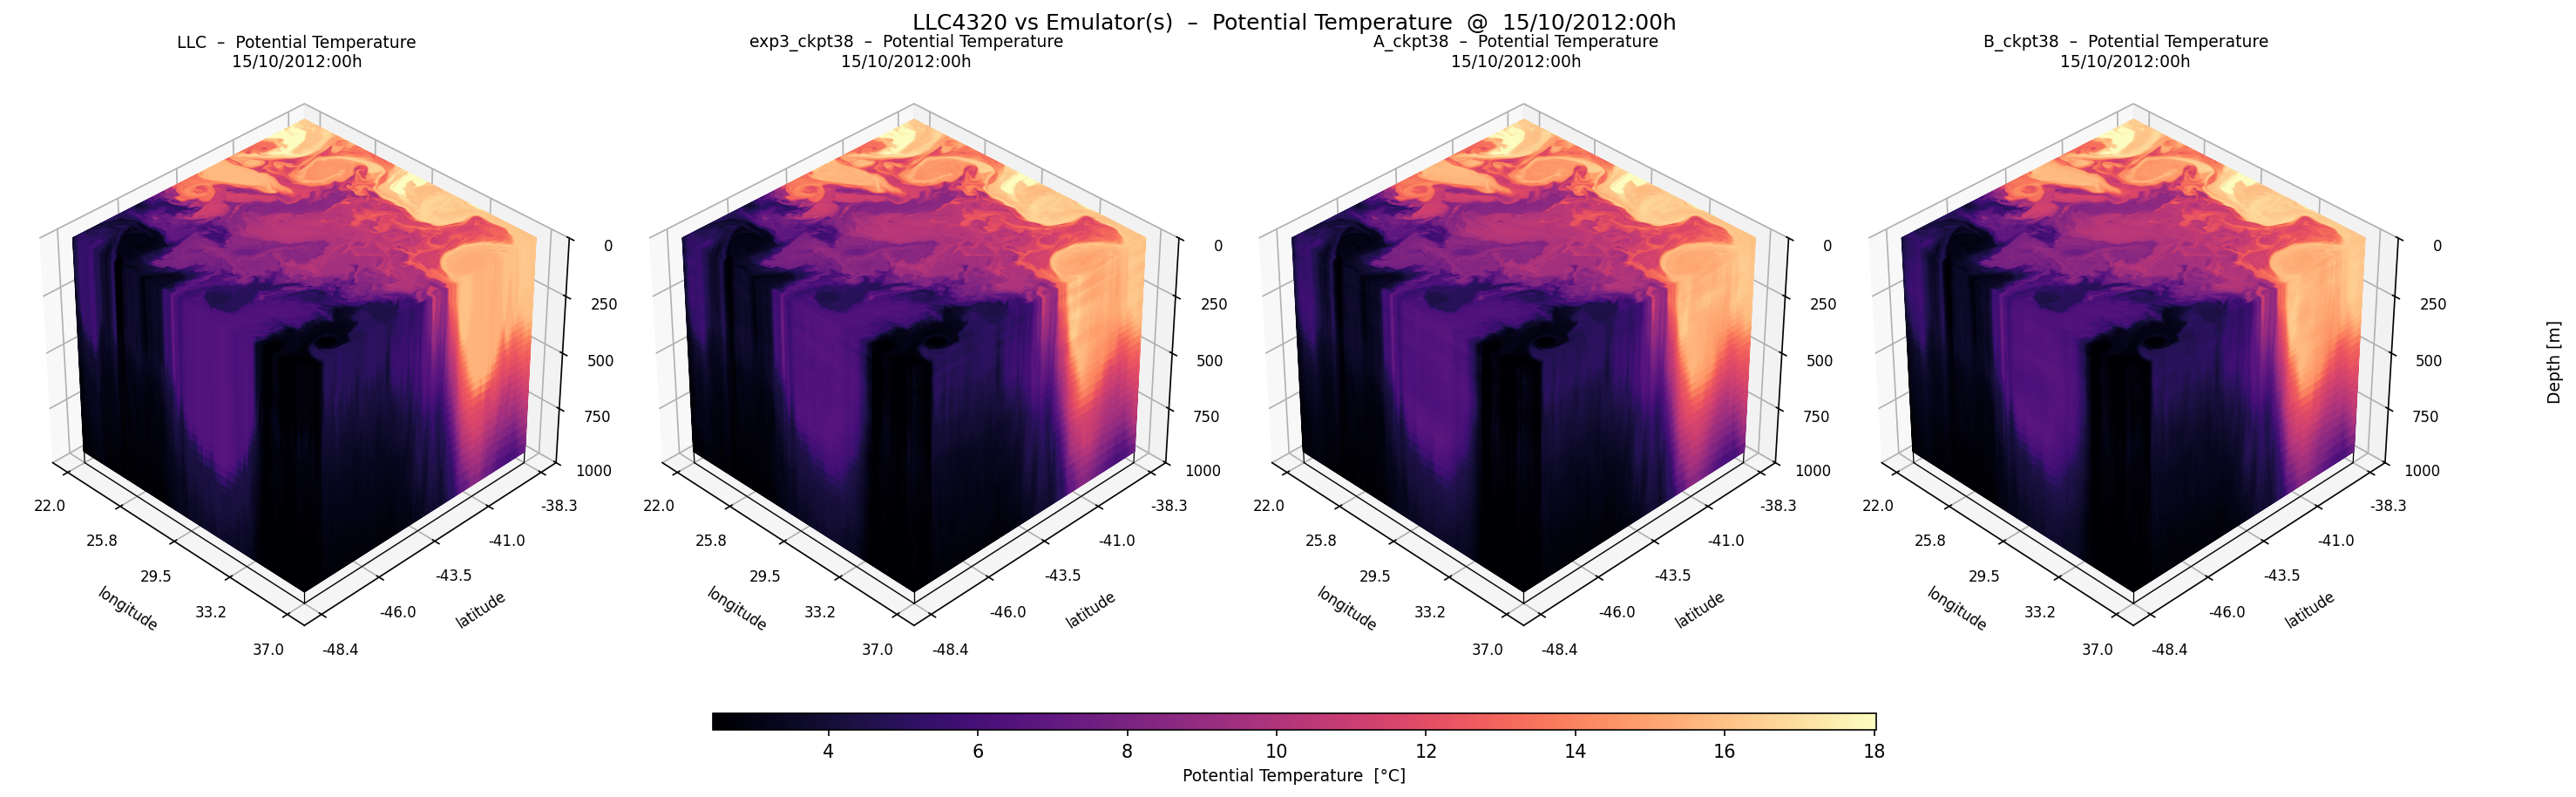

In [5]:
# ============================================================
#  3-D COMPARISON PLOT  –  LLC vs. Emulator(s)
# ============================================================

# ── USER SETTINGS ────────────────────────────────────────────────────────
plot_time_idx  = 3           # index into the synchronised time axis
plot_vars      = ['Theta']   # variables to plot (one figure per variable)
transect_i     = 720         # east-wall i-slice  (surface spans i = 0 … transect_i)
transect_j     = 720         # south-wall j-slice (surface spans j = 0 … transect_j)
k_max          = 51          # depth levels to include  (k = 0 … k_max − 1)
plot_stride    = 1           # horizontal downsampling stride (1 = full-res, slow)
# ─────────────────────────────────────────────────────────────────────────

# ── Colour map ───────────────────────────────────────────────────────────
cmap_3d = plt.cm.magma

# ── Domain bounds derived from transect selections ───────────────────────
i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
s = plot_stride

# ── Coordinate arrays ────────────────────────────────────────────────────
i_vals = None  # filled from extracted block shapes below
j_vals = None

# ── Ordered source list: LLC first, then emulators ───────────────────────
sources = [('LLC', llc_patch)] + [
    (name, emulator_patches[key]) for name, key in emulator_info
]
n_cols = len(sources)

# ── Helpers ───────────────────────────────────────────────────────────────
def _pick_dim_cmp(dims, candidates, label):
    for name in candidates:
        if name in dims:
            return name
    raise ValueError(f"Could not find {label} dimension in {tuple(dims)}")


def _get_dim_names_cmp(patch, var):
    dims = patch[var].dims
    k_dim = _pick_dim_cmp(dims, ('k', 'Z', 'depth', 'lev'), 'vertical')
    j_dim = _pick_dim_cmp(dims, ('j', 'lat', 'y'), 'north-south')
    i_dim = _pick_dim_cmp(dims, ('i', 'lon', 'x'), 'east-west')
    return k_dim, j_dim, i_dim


# ── Helper: extract the 3-D block from any patch ─────────────────────────
def _get_block(patch, t_idx, var):
    k_dim, j_dim, i_dim = _get_dim_names_cmp(patch, var)
    sub = patch.isel(**{
        'time': t_idx,
        i_dim : slice(i_0, i_1 + 1),
        j_dim : slice(j_0, j_1 + 1),
        k_dim : slice(0, k_max),
    })

    data = sub[var].transpose(k_dim, j_dim, i_dim).values  # (k, j, i)
    z = sub["Z"].values

    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]

    return data, z.ravel()


def _coord_block_cmp(patch, name, n_j, n_i):
    coord = patch[name]
    j_dim = _pick_dim_cmp(coord.dims, ('j', 'lat', 'y'), f'{name} north-south')
    i_dim = _pick_dim_cmp(coord.dims, ('i', 'lon', 'x'), f'{name} east-west')
    sel = coord.isel({
        j_dim: slice(j_0, j_0 + n_j),
        i_dim: slice(i_0, i_0 + n_i),
    })
    for extra_dim in set(sel.dims) - {j_dim, i_dim}:
        sel = sel.isel({extra_dim: 0})
    return sel.transpose(j_dim, i_dim).values


def _nice_lon_lat_ticks_cmp(coord_2d, axis_vals, axis):
    idx = np.linspace(0, len(axis_vals) - 1, 5).round().astype(int)
    pos = axis_vals[idx]
    if axis == 'i':
        coord_vals = coord_2d[coord_2d.shape[0] // 2, idx]
    else:
        coord_vals = coord_2d[idx, coord_2d.shape[1] // 2]
    return pos, [f'{v:.1f}' for v in coord_vals]


# ── Helper: return only arrays that are actually plotted ─────────────────
def _get_plotted_faces(var):
    """
    Extract only the values that are sent to plot_surface.

    Returns:
        top surface: var[0, ::s, ::s]
        south wall: var[:, 0, ::s]
        east wall:  var[:, ::s, -1]
    """
    return [
        var[0, ::s, ::s],    # surface face, k = 0
        var[:, 0, ::s],      # south wall, j = 0
        var[:, ::s, -1],     # east wall, i = i_1
    ]


# ── Time label ───────────────────────────────────────────────────────────
time_str = format_time(llc_patch.time.values[plot_time_idx])

# os.makedirs('figs/3d_comparison', exist_ok=True)

# ── One figure per variable ──────────────────────────────────────────────
for plot_var in plot_vars:

    # Pre-fetch all blocks
    blocks = {
        label: _get_block(patch, plot_time_idx, plot_var)
        for label, patch in sources
    }

    n_k, n_j, n_i = blocks['LLC'][0].shape
    i_vals = np.arange(i_0, i_0 + n_i)
    j_vals = np.arange(j_0, j_0 + n_j)
    i_plot_1 = float(i_vals[-1])
    j_plot_1 = float(j_vals[-1])
    xc_block = _coord_block_cmp(llc_patch, 'XC', n_j, n_i)
    yc_block = _coord_block_cmp(llc_patch, 'YC', n_j, n_i)
    x_tick_pos, x_tick_labels = _nice_lon_lat_ticks_cmp(xc_block, i_vals, 'i')
    y_tick_pos, y_tick_labels = _nice_lon_lat_ticks_cmp(yc_block, j_vals, 'j')

    # ---------------------------------------------------------------------
    # Colour limits based ONLY on values that are actually plotted:
    #   ① surface face
    #   ② south wall
    #   ③ east wall
    #
    # This excludes the unplotted interior volume.
    # ---------------------------------------------------------------------
    plotted_values = []

    for var, _ in blocks.values():
        for face in _get_plotted_faces(var):
            plotted_values.append(face.ravel())

    plotted_values = np.concatenate(plotted_values)
    plotted_values = plotted_values[np.isfinite(plotted_values)]

    vmin = float(np.nanpercentile(plotted_values, 1))
    vmax = float(np.nanpercentile(plotted_values, 99))

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def to_fc(arr, _n=norm, _c=cmap_3d):
        """Data array → RGBA face-colour array."""
        return _c(_n(arr))

    # ── Figure: 1 row × n_cols subplots ──────────────────────────────────
    fig = plt.figure(figsize=(5.3 * n_cols, 6.2), dpi=150)
    fig.subplots_adjust(left=0.03, right=0.91, bottom=0.18, top=0.88, wspace=0.00)

    for col, (label, _) in enumerate(sources):
        var, z_vals = blocks[label]

        depth_vals = -z_vals
        z_top = 0.0
        z_bot = 1000.0

        ax = fig.add_subplot(1, n_cols, col + 1, projection="3d")

        # ① Surface face  (k = 0) -----------------------------------------
        I_s, J_s = np.meshgrid(i_vals[::s], j_vals[::s])

        ax.plot_surface(
            I_s,
            J_s,
            np.full_like(I_s, z_top, dtype=float),
            facecolors=to_fc(var[0, ::s, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ② South wall  (j = 0) -------------------------------------------
        I_j, Z_j = np.meshgrid(i_vals[::s], depth_vals)

        ax.plot_surface(
            I_j,
            np.full_like(I_j, float(j_0)),
            Z_j,
            facecolors=to_fc(var[:, 0, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ③ East wall  (i = transect_i) -----------------------------------
        J_i, Z_i = np.meshgrid(j_vals[::s], depth_vals)

        ax.plot_surface(
            np.full_like(J_i, i_plot_1),
            J_i,
            Z_i,
            facecolors=to_fc(var[:, ::s, -1]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ── Box outline edges ─────────────────────────────────────────────
        ek = dict(color="k", linewidth=0.6)

        # Top rectangle
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[0], j_vals[0]], [z_top, z_top], **ek)
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[-1], j_vals[-1]], [z_top, z_top], **ek)
        ax.plot([i_vals[0], i_vals[0]], [j_vals[0], j_vals[-1]], [z_top, z_top], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[-1]], [z_top, z_top], **ek)

        # Bottom edges of the two visible walls
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[0], j_vals[0]], [z_bot, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[-1]], [z_bot, z_bot], **ek)

        # Vertical edges
        ax.plot([i_vals[0], i_vals[0]], [j_vals[0], j_vals[0]], [z_top, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[0]], [z_top, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[-1], j_vals[-1]], [z_top, z_bot], **ek)

        ax.view_init(elev=35, azim=-45)

        ax.set_xticks(x_tick_pos)
        ax.set_xticklabels(x_tick_labels, fontsize=8)
        ax.set_yticks(y_tick_pos)
        ax.set_yticklabels(y_tick_labels, fontsize=8)
        ax.set_xlabel("longitude", labelpad=8, fontsize=8)
        ax.set_ylabel("latitude", labelpad=8, fontsize=8)
        ax.set_zlim(1000.0, 0.0)
        ax.set_zticks([0, 250, 500, 750, 1000])
        ax.set_zlabel("")
        ax.tick_params(axis='z', labelsize=8, pad=4)

        ax.set_title(
            f"{label}  –  {'Potential Temperature' if plot_var == 'Theta' else plot_var}\n{time_str}",
            fontsize=9,
        )

    fig.text(0.955, 0.53, "Depth [m]", rotation=90,
             ha='center', va='center', fontsize=9)

    # ── Single shared colour bar for all panels ──────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap_3d, norm=norm)
    sm.set_array([])

    cbar_label = "Potential Temperature  [°C]" if plot_var == "Theta" else plot_var
    cb_w = 0.42
    cb_h = 0.020
    ax_cb = fig.add_axes([0.5 - 0.5 * cb_w, 0.075, cb_w, cb_h])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.set_label(cbar_label, fontsize=9)

    plt.suptitle(
        f"LLC4320 vs Emulator(s)  –  {'Potential Temperature' if plot_var == 'Theta' else plot_var}  @  {time_str}",
        fontsize=12,
        y=0.96,
    )

    out_path = f"figs/3d_comparison/3d_{plot_var}_{plot_time_idx:03d}.png"

    # plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    # plt.close()
    # print(f"✓  {plot_var}  →  {out_path}")

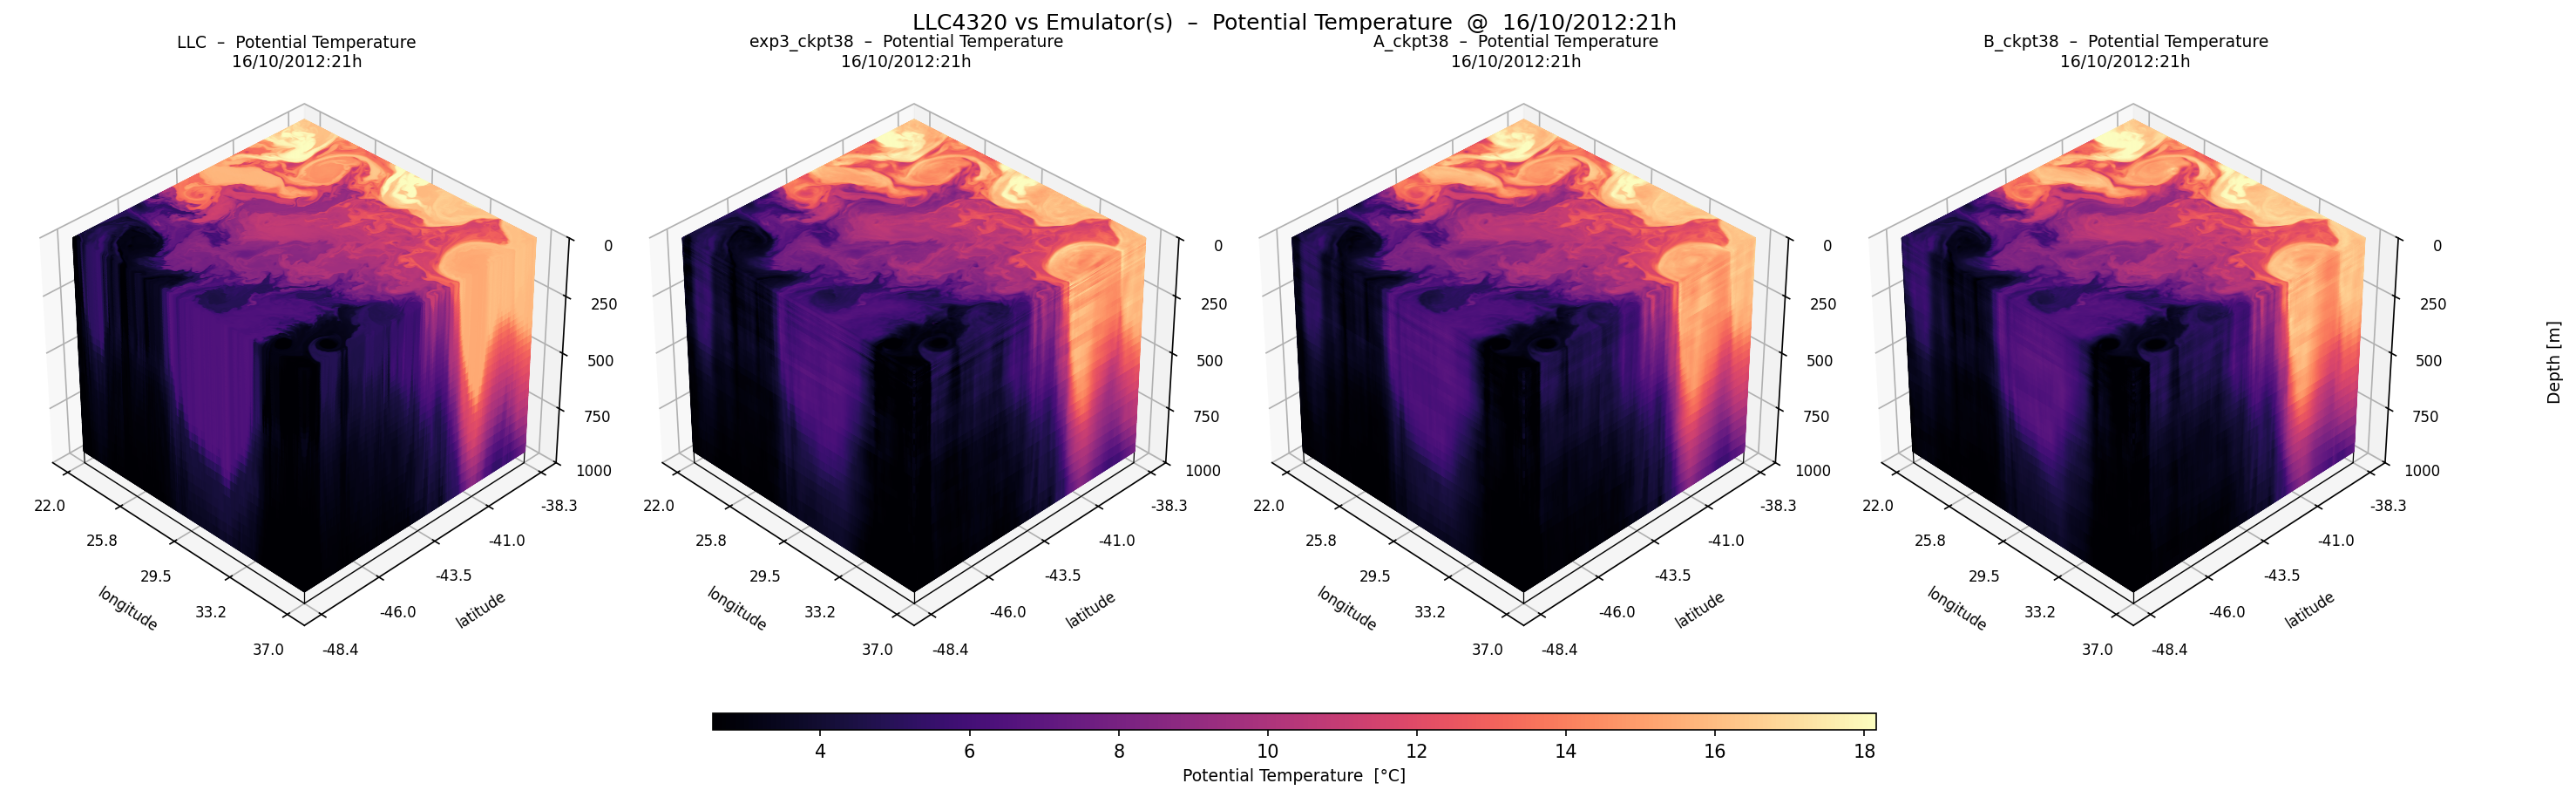

In [6]:
# ============================================================
#  3-D COMPARISON PLOT  –  LLC vs. Emulator(s)
# ============================================================

# ── USER SETTINGS ────────────────────────────────────────────────────────
plot_time_idx  = 18           # index into the synchronised time axis
plot_vars      = ['Theta']   # variables to plot (one figure per variable)
transect_i     = 720         # east-wall i-slice  (surface spans i = 0 … transect_i)
transect_j     = 720         # south-wall j-slice (surface spans j = 0 … transect_j)
k_max          = 51          # depth levels to include  (k = 0 … k_max − 1)
plot_stride    = 1           # horizontal downsampling stride (1 = full-res, slow)
# ─────────────────────────────────────────────────────────────────────────

# ── Colour map ───────────────────────────────────────────────────────────
cmap_3d = plt.cm.magma

# ── Domain bounds derived from transect selections ───────────────────────
i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
s = plot_stride

# ── Coordinate arrays ────────────────────────────────────────────────────
i_vals = None  # filled from extracted block shapes below
j_vals = None

# ── Ordered source list: LLC first, then emulators ───────────────────────
sources = [('LLC', llc_patch)] + [
    (name, emulator_patches[key]) for name, key in emulator_info
]
n_cols = len(sources)

# ── Helpers ───────────────────────────────────────────────────────────────
def _pick_dim_cmp(dims, candidates, label):
    for name in candidates:
        if name in dims:
            return name
    raise ValueError(f"Could not find {label} dimension in {tuple(dims)}")


def _get_dim_names_cmp(patch, var):
    dims = patch[var].dims
    k_dim = _pick_dim_cmp(dims, ('k', 'Z', 'depth', 'lev'), 'vertical')
    j_dim = _pick_dim_cmp(dims, ('j', 'lat', 'y'), 'north-south')
    i_dim = _pick_dim_cmp(dims, ('i', 'lon', 'x'), 'east-west')
    return k_dim, j_dim, i_dim


# ── Helper: extract the 3-D block from any patch ─────────────────────────
def _get_block(patch, t_idx, var):
    k_dim, j_dim, i_dim = _get_dim_names_cmp(patch, var)
    sub = patch.isel(**{
        'time': t_idx,
        i_dim : slice(i_0, i_1 + 1),
        j_dim : slice(j_0, j_1 + 1),
        k_dim : slice(0, k_max),
    })

    data = sub[var].transpose(k_dim, j_dim, i_dim).values  # (k, j, i)
    z = sub["Z"].values

    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]

    return data, z.ravel()


def _coord_block_cmp(patch, name, n_j, n_i):
    coord = patch[name]
    j_dim = _pick_dim_cmp(coord.dims, ('j', 'lat', 'y'), f'{name} north-south')
    i_dim = _pick_dim_cmp(coord.dims, ('i', 'lon', 'x'), f'{name} east-west')
    sel = coord.isel({
        j_dim: slice(j_0, j_0 + n_j),
        i_dim: slice(i_0, i_0 + n_i),
    })
    for extra_dim in set(sel.dims) - {j_dim, i_dim}:
        sel = sel.isel({extra_dim: 0})
    return sel.transpose(j_dim, i_dim).values


def _nice_lon_lat_ticks_cmp(coord_2d, axis_vals, axis):
    idx = np.linspace(0, len(axis_vals) - 1, 5).round().astype(int)
    pos = axis_vals[idx]
    if axis == 'i':
        coord_vals = coord_2d[coord_2d.shape[0] // 2, idx]
    else:
        coord_vals = coord_2d[idx, coord_2d.shape[1] // 2]
    return pos, [f'{v:.1f}' for v in coord_vals]


# ── Helper: return only arrays that are actually plotted ─────────────────
def _get_plotted_faces(var):
    """
    Extract only the values that are sent to plot_surface.

    Returns:
        top surface: var[0, ::s, ::s]
        south wall: var[:, 0, ::s]
        east wall:  var[:, ::s, -1]
    """
    return [
        var[0, ::s, ::s],    # surface face, k = 0
        var[:, 0, ::s],      # south wall, j = 0
        var[:, ::s, -1],     # east wall, i = i_1
    ]


# ── Time label ───────────────────────────────────────────────────────────
time_str = format_time(llc_patch.time.values[plot_time_idx])

# os.makedirs('figs/3d_comparison', exist_ok=True)

# ── One figure per variable ──────────────────────────────────────────────
for plot_var in plot_vars:

    # Pre-fetch all blocks
    blocks = {
        label: _get_block(patch, plot_time_idx, plot_var)
        for label, patch in sources
    }

    n_k, n_j, n_i = blocks['LLC'][0].shape
    i_vals = np.arange(i_0, i_0 + n_i)
    j_vals = np.arange(j_0, j_0 + n_j)
    i_plot_1 = float(i_vals[-1])
    j_plot_1 = float(j_vals[-1])
    xc_block = _coord_block_cmp(llc_patch, 'XC', n_j, n_i)
    yc_block = _coord_block_cmp(llc_patch, 'YC', n_j, n_i)
    x_tick_pos, x_tick_labels = _nice_lon_lat_ticks_cmp(xc_block, i_vals, 'i')
    y_tick_pos, y_tick_labels = _nice_lon_lat_ticks_cmp(yc_block, j_vals, 'j')

    # ---------------------------------------------------------------------
    # Colour limits based ONLY on values that are actually plotted:
    #   ① surface face
    #   ② south wall
    #   ③ east wall
    #
    # This excludes the unplotted interior volume.
    # ---------------------------------------------------------------------
    plotted_values = []

    for var, _ in blocks.values():
        for face in _get_plotted_faces(var):
            plotted_values.append(face.ravel())

    plotted_values = np.concatenate(plotted_values)
    plotted_values = plotted_values[np.isfinite(plotted_values)]

    vmin = float(np.nanpercentile(plotted_values, 1))
    vmax = float(np.nanpercentile(plotted_values, 99))

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def to_fc(arr, _n=norm, _c=cmap_3d):
        """Data array → RGBA face-colour array."""
        return _c(_n(arr))

    # ── Figure: 1 row × n_cols subplots ──────────────────────────────────
    fig = plt.figure(figsize=(5.3 * n_cols, 6.2), dpi=150)
    fig.subplots_adjust(left=0.03, right=0.91, bottom=0.18, top=0.88, wspace=0.00)

    for col, (label, _) in enumerate(sources):
        var, z_vals = blocks[label]

        depth_vals = -z_vals
        z_top = 0.0
        z_bot = 1000.0

        ax = fig.add_subplot(1, n_cols, col + 1, projection="3d")

        # ① Surface face  (k = 0) -----------------------------------------
        I_s, J_s = np.meshgrid(i_vals[::s], j_vals[::s])

        ax.plot_surface(
            I_s,
            J_s,
            np.full_like(I_s, z_top, dtype=float),
            facecolors=to_fc(var[0, ::s, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ② South wall  (j = 0) -------------------------------------------
        I_j, Z_j = np.meshgrid(i_vals[::s], depth_vals)

        ax.plot_surface(
            I_j,
            np.full_like(I_j, float(j_0)),
            Z_j,
            facecolors=to_fc(var[:, 0, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ③ East wall  (i = transect_i) -----------------------------------
        J_i, Z_i = np.meshgrid(j_vals[::s], depth_vals)

        ax.plot_surface(
            np.full_like(J_i, i_plot_1),
            J_i,
            Z_i,
            facecolors=to_fc(var[:, ::s, -1]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ── Box outline edges ─────────────────────────────────────────────
        ek = dict(color="k", linewidth=0.6)

        # Top rectangle
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[0], j_vals[0]], [z_top, z_top], **ek)
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[-1], j_vals[-1]], [z_top, z_top], **ek)
        ax.plot([i_vals[0], i_vals[0]], [j_vals[0], j_vals[-1]], [z_top, z_top], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[-1]], [z_top, z_top], **ek)

        # Bottom edges of the two visible walls
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[0], j_vals[0]], [z_bot, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[-1]], [z_bot, z_bot], **ek)

        # Vertical edges
        ax.plot([i_vals[0], i_vals[0]], [j_vals[0], j_vals[0]], [z_top, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[0]], [z_top, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[-1], j_vals[-1]], [z_top, z_bot], **ek)

        ax.view_init(elev=35, azim=-45)

        ax.set_xticks(x_tick_pos)
        ax.set_xticklabels(x_tick_labels, fontsize=8)
        ax.set_yticks(y_tick_pos)
        ax.set_yticklabels(y_tick_labels, fontsize=8)
        ax.set_xlabel("longitude", labelpad=8, fontsize=8)
        ax.set_ylabel("latitude", labelpad=8, fontsize=8)
        ax.set_zlim(1000.0, 0.0)
        ax.set_zticks([0, 250, 500, 750, 1000])
        ax.set_zlabel("")
        ax.tick_params(axis='z', labelsize=8, pad=4)

        ax.set_title(
            f"{label}  –  {'Potential Temperature' if plot_var == 'Theta' else plot_var}\n{time_str}",
            fontsize=9,
        )

    fig.text(0.955, 0.53, "Depth [m]", rotation=90,
             ha='center', va='center', fontsize=9)

    # ── Single shared colour bar for all panels ──────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap_3d, norm=norm)
    sm.set_array([])

    cbar_label = "Potential Temperature  [°C]" if plot_var == "Theta" else plot_var
    cb_w = 0.42
    cb_h = 0.020
    ax_cb = fig.add_axes([0.5 - 0.5 * cb_w, 0.075, cb_w, cb_h])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.set_label(cbar_label, fontsize=9)

    plt.suptitle(
        f"LLC4320 vs Emulator(s)  –  {'Potential Temperature' if plot_var == 'Theta' else plot_var}  @  {time_str}",
        fontsize=12,
        y=0.96,
    )

    out_path = f"figs/3d_comparison/3d_{plot_var}_{plot_time_idx:03d}.png"

    # plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    # plt.close()
    # print(f"✓  {plot_var}  →  {out_path}")

Extracting face data …
  ✓  LLC  |  θ (720, 720)  KE (51, 720)  B (51, 720)
  ✓  exp3_ckpt24  |  θ (720, 720)  KE (51, 720)  B (51, 720)


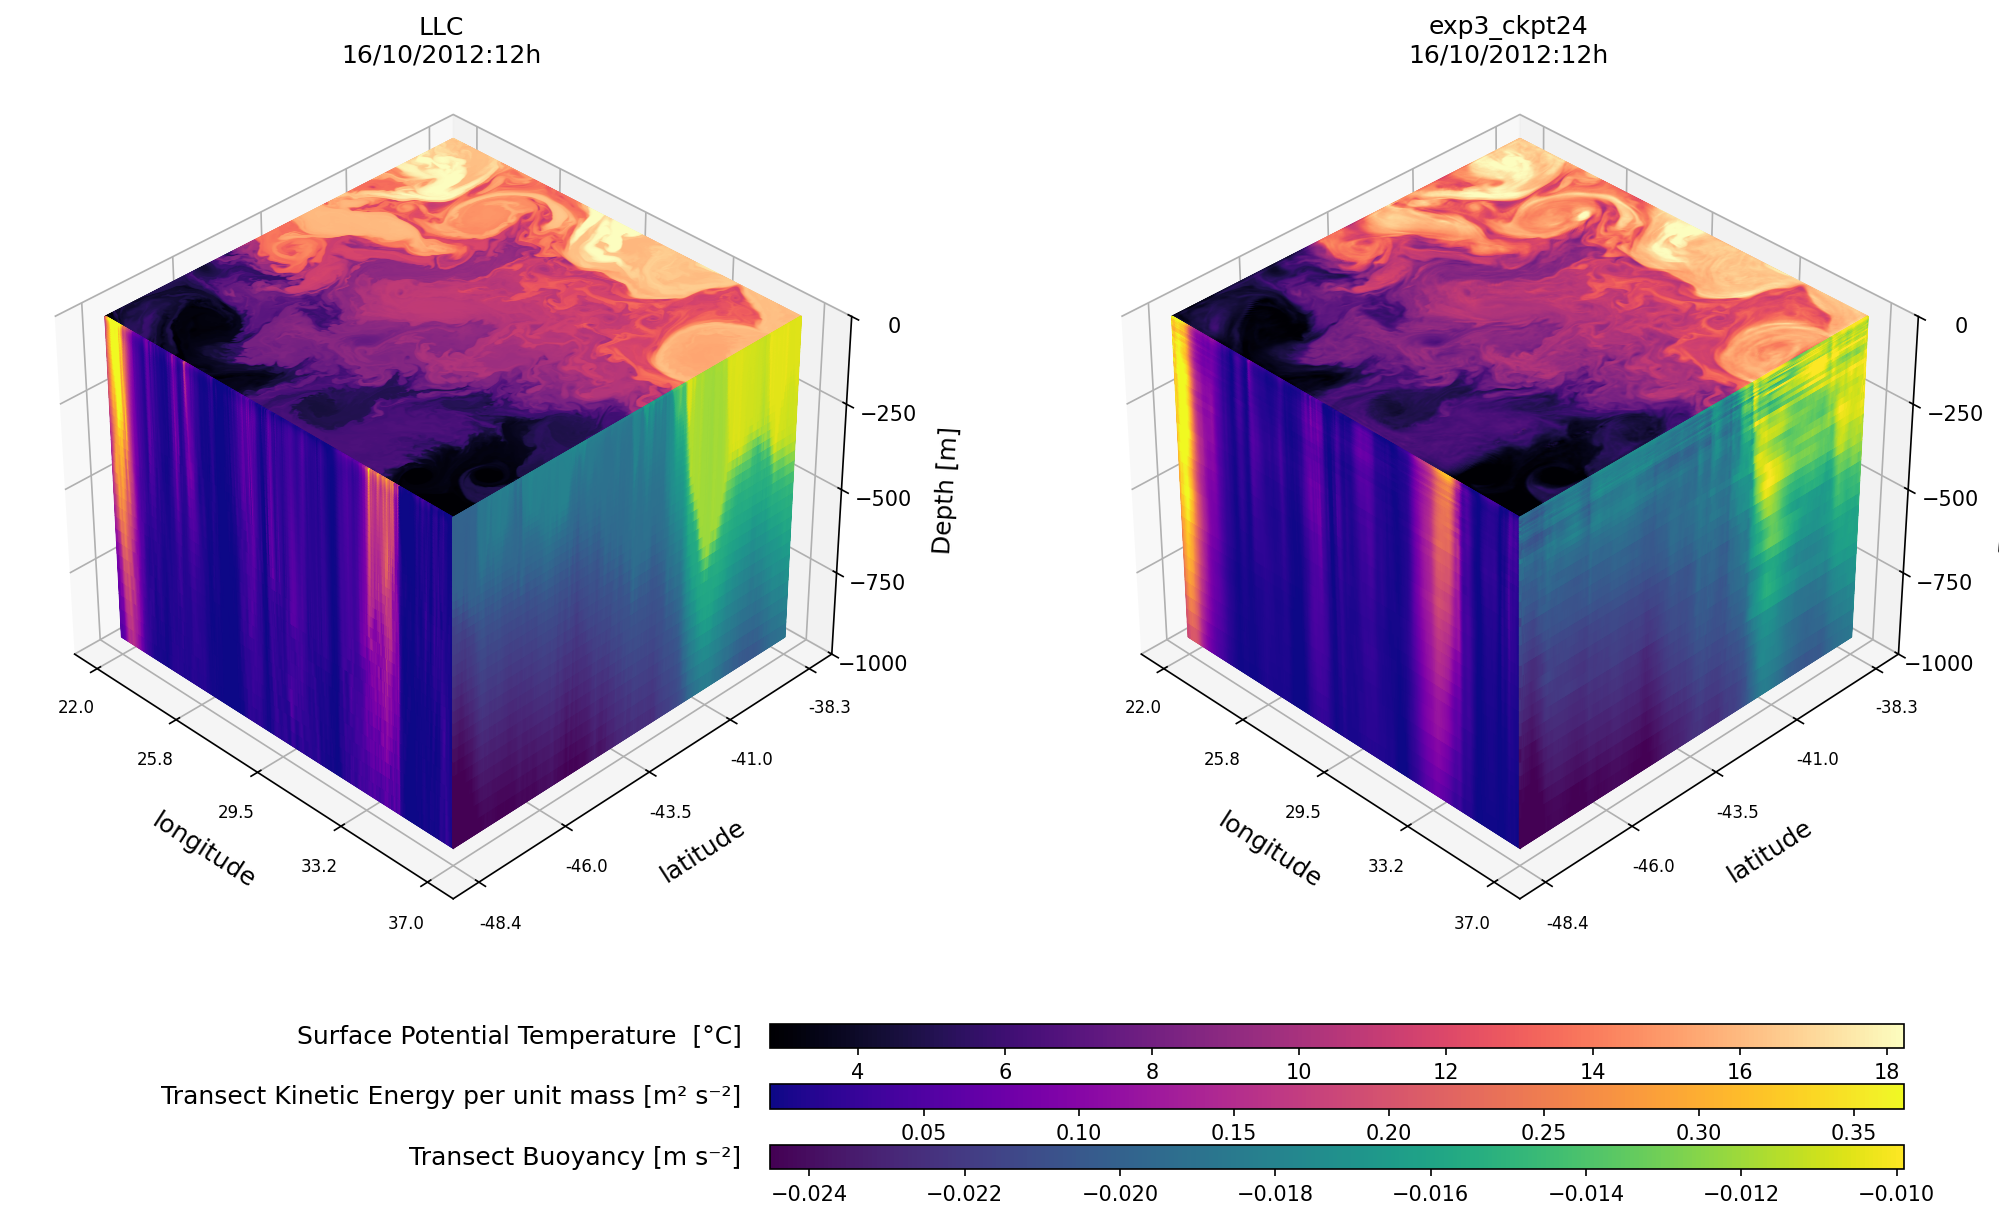

In [7]:
# ============================================================
#  3-D COMPOSITE FIGURE
#  Surface:      Theta  (magma)  – shared norm across sources
#  South wall:   KE     (plasma)      – constant-j transect
#  East wall:    B      (viridis)     – constant-i transect
# ============================================================

# ── USER SETTINGS ─────────────────────────────────────────────────────────
plot_time_idx = 15
transect_i    = 720    # east-wall i;   surface/south-wall span i = 0 … transect_i
transect_j    = 720    # south-wall j;  surface/east-wall  span j = 0 … transect_j
k_max         = 51
plot_stride   = 1
# ──────────────────────────────────────────────────────────────────────────

G    = 9.81
rho0 = 1025.0

i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
s         = plot_stride

i_vals = None  # filled from extracted block shapes below
j_vals = None

cmap_theta = plt.cm.magma
cmap_B     = plt.cm.viridis
cmap_KE    = plt.cm.plasma

sources  = [('LLC', llc_patch)] + [
    (name, emulator_patches[key]) for name, key in emulator_info
]
n_cols   = len(sources)
time_str = format_time(llc_patch.time.values[plot_time_idx])


# ── Dimension detection ───────────────────────────────────────────────────
def _pick_dim(dims, candidates, label):
    for name in candidates:
        if name in dims:
            return name
    raise ValueError(f"Could not find {label} dimension in {tuple(dims)}")


def _dims(patch, var):
    """(k_dim, j_dim, i_dim) for a specific variable, including staggered axes."""
    d = patch[var].dims
    kd = _pick_dim(d, ('k', 'Z', 'depth', 'lev'), 'vertical')
    jd = _pick_dim(d, ('j', 'j_g', 'lat', 'y'), 'north-south')
    id_ = _pick_dim(d, ('i', 'i_g', 'lon', 'x'), 'east-west')
    return kd, jd, id_


# ── Efficient per-face extractors ─────────────────────────────────────────
# Each function reads only the slice needed — no full-volume arrays allocated.

def _surface_theta(patch, t_idx):
    """Theta at k=0, full j×i surface  →  (j, i)."""
    kd, jd, id_ = _dims(patch, 'Theta')
    sub = patch.isel(**{
        'time': t_idx,
        kd    : 0,
        jd    : slice(j_0, j_1 + 1),
        id_   : slice(i_0, i_1 + 1),
    })
    return sub['Theta'].transpose(jd, id_).values          # (j, i)


def _south_wall_KE(patch, t_idx):
    """KE at constant j=j_0 south wall  →  (k, i)."""
    kd_u, jd_u, id_u = _dims(patch, 'U')
    sub_u = patch['U'].isel({
        'time': t_idx,
        kd_u  : slice(0, k_max),
        jd_u  : j_0,
        id_u  : slice(i_0, i_1 + 1),
    })
    U = sub_u.transpose(kd_u, id_u).values                 # (k, i-like)

    kd_v, jd_v, id_v = _dims(patch, 'V')
    sub_v = patch['V'].isel({
        'time': t_idx,
        kd_v  : slice(0, k_max),
        jd_v  : j_0,
        id_v  : slice(i_0, i_1 + 1),
    })
    V = sub_v.transpose(kd_v, id_v).values                 # (k, i-like)

    n_k = min(U.shape[0], V.shape[0])
    n_i = min(U.shape[1], V.shape[1])
    U = U[:n_k, :n_i]
    V = V[:n_k, :n_i]
    return 0.5 * (U**2 + V**2)                             # (k, i)


def _east_wall_B(patch, t_idx):
    """
    Buoyancy at constant i=i_1 east wall  →  (k, j).
    Selects the i-block first then takes isel(-1) so the call is
    safe even when i_1 equals the patch size (no out-of-bounds error).
    """
    kd, jd, id_ = _dims(patch, 'Salt')
    sub = patch.isel(**{
        'time': t_idx,
        kd    : slice(0, k_max),
        jd    : slice(j_0, j_1 + 1),
        id_   : slice(i_0, i_1 + 1),
    }).isel(**{id_: -1})                                   # last i in block
    Salt  = sub['Salt'].transpose(kd, jd).values           # (k, j)
    kd_t, jd_t, id_t = _dims(patch, 'Theta')
    theta_sub = patch['Theta'].isel({
        'time': t_idx,
        kd_t  : slice(0, k_max),
        jd_t  : slice(j_0, j_1 + 1),
        id_t  : slice(i_0, i_1 + 1),
    }).isel(**{id_t: -1})
    Theta = theta_sub.transpose(kd_t, jd_t).values         # (k, j)
    n_k = min(Salt.shape[0], Theta.shape[0])
    n_j = min(Salt.shape[1], Theta.shape[1])
    Salt = Salt[:n_k, :n_j]
    Theta = Theta[:n_k, :n_j]
    sigma0 = jmd95numba.rho(Salt, Theta, 0) - rho0
    return -G * sigma0 / rho0                              # (k, j)


def _get_z(patch, t_idx):
    """Depth coordinate vector  →  (k,)."""
    kd = _pick_dim(patch['Z'].dims, ('k', 'Z', 'depth', 'lev'), 'Z vertical')
    sub = patch.isel(**{'time': t_idx, kd: slice(0, k_max)})
    z = sub['Z'].values
    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]
    return z.ravel()


def _coord_block(patch, name, n_j, n_i):
    """Grid coordinate block, returned as (j, i) when available."""
    coord = patch[name]
    jd = _pick_dim(coord.dims, ('j', 'lat', 'y'), f'{name} north-south')
    id_ = _pick_dim(coord.dims, ('i', 'lon', 'x'), f'{name} east-west')
    sel = coord.isel({
        jd: slice(j_0, j_0 + n_j),
        id_: slice(i_0, i_0 + n_i),
    })
    for extra_dim in set(sel.dims) - {jd, id_}:
        sel = sel.isel({extra_dim: 0})
    return sel.transpose(jd, id_).values


def _nice_lon_lat_ticks(coord_2d, axis_vals, axis):
    """Even local-index tick positions with lon/lat labels from XC/YC."""
    n_ticks = 5
    idx = np.linspace(0, len(axis_vals) - 1, n_ticks).round().astype(int)
    pos = axis_vals[idx]
    if axis == 'i':
        coord_vals = coord_2d[coord_2d.shape[0] // 2, idx]
    else:
        coord_vals = coord_2d[idx, coord_2d.shape[1] // 2]
    labels = [f'{v:.1f}' for v in coord_vals]
    return pos, labels


# ── Fetch all data blocks ─────────────────────────────────────────────────
print("Extracting face data …")
blocks = {}
for label, patch in sources:
    blocks[label] = {
        'theta_surf': _surface_theta(patch, plot_time_idx),
        'KE_south'  : _south_wall_KE(patch, plot_time_idx),
        'B_east'    : _east_wall_B(  patch, plot_time_idx),
    }
    print(f"  ✓  {label}  |  "
          f"θ {blocks[label]['theta_surf'].shape}  "
          f"KE {blocks[label]['KE_south'].shape}  "
          f"B {blocks[label]['B_east'].shape}")

n_j, n_i = blocks['LLC']['theta_surf'].shape
i_vals = np.arange(i_0, i_0 + n_i)
j_vals = np.arange(j_0, j_0 + n_j)
i_plot_1 = float(i_vals[-1])
j_plot_1 = float(j_vals[-1])
xc_block = _coord_block(llc_patch, 'XC', n_j, n_i)
yc_block = _coord_block(llc_patch, 'YC', n_j, n_i)
x_tick_pos, x_tick_labels = _nice_lon_lat_ticks(xc_block, i_vals, 'i')
y_tick_pos, y_tick_labels = _nice_lon_lat_ticks(yc_block, j_vals, 'j')

z_vals = _get_z(llc_patch, plot_time_idx)
z_top  = float(z_vals[0])
z_bot  = float(z_vals[-1])
z_axis_bot = min(z_bot, -1000.0)
z_axis_top = max(0.0, z_top)
z_tick_vals = np.array([0.0, -250.0, -500.0, -750.0, -1000.0])


# ── Shared colour norms (per face, pooled across all sources) ─────────────
def _norm(key):
    """1st–99th percentile norm over all sources for one face key."""
    vals = np.concatenate([blocks[lbl][key].ravel() for lbl, _ in sources])
    vals = vals[np.isfinite(vals)]
    return mcolors.Normalize(
        vmin=float(np.nanpercentile(vals, 1)),
        vmax=float(np.nanpercentile(vals, 99)),
    )

norm_theta = _norm('theta_surf')
norm_KE    = _norm('KE_south')
norm_B     = _norm('B_east')

# Default-arg trick freezes each norm/cmap at definition time
to_fc_theta = lambda a, _n=norm_theta, _c=cmap_theta: _c(_n(a))
to_fc_KE    = lambda a, _n=norm_KE,    _c=cmap_KE:    _c(_n(a))
to_fc_B     = lambda a, _n=norm_B,     _c=cmap_B:     _c(_n(a))


# ── Figure layout ─────────────────────────────────────────────────────────
#
#   [B cbar]  |  [3-D: LLC]  [3-D: Emu1]  …  |  [KE cbar]
#                  [Θ cbar below LLC]
#
FIG_L, FIG_R = 0.10, 0.90
FIG_B, FIG_T = 0.15, 0.92
sp_w         = (FIG_R - FIG_L) / n_cols   # per-column width in figure coords
CB_W         = 0.018                       # colorbar strip width

fig = plt.figure(figsize=(7 * n_cols + 2, 9), dpi=150)
fig.subplots_adjust(left=FIG_L, right=FIG_R,
                    bottom=FIG_B, top=FIG_T, wspace=0.25)

axes_3d = [fig.add_subplot(1, n_cols, c + 1, projection='3d')
           for c in range(n_cols)]


# ── Plot each column ──────────────────────────────────────────────────────
for col, (label, _) in enumerate(sources):
    ax = axes_3d[col]
    b  = blocks[label]

    # ① Surface (k=0) – Theta ────────────────────────────────────────────
    I_s, J_s = np.meshgrid(i_vals[::s], j_vals[::s])
    ax.plot_surface(
        I_s, J_s, np.full_like(I_s, z_top, dtype=float),
        facecolors=to_fc_theta(b['theta_surf'][::s, ::s]),
        shade=False, rstride=1, cstride=1,
    )

    # ② South wall (j=j_0) – KE ──────────────────────────────────────────
    I_j, Z_j = np.meshgrid(i_vals[::s], z_vals)
    ax.plot_surface(
        I_j, np.full_like(I_j, float(j_0)), Z_j,
        facecolors=to_fc_KE(b['KE_south'][:, ::s]),
        shade=False, rstride=1, cstride=1,
    )

    # ③ East wall (i=i_1) – B ────────────────────────────────────────────
    J_i, Z_i = np.meshgrid(j_vals[::s], z_vals)
    ax.plot_surface(
        np.full_like(J_i, i_plot_1), J_i, Z_i,
        facecolors=to_fc_B(b['B_east'][:, ::s]),
        shade=False, rstride=1, cstride=1,
    )

    # ── Box edges ─────────────────────────────────────────────────────────
    ek = dict(color='k', linewidth=0.6)
    ax.plot([i_0, i_plot_1], [j_0, j_0], [z_top, z_top], **ek)
    ax.plot([i_0, i_plot_1], [j_plot_1, j_plot_1], [z_top, z_top], **ek)
    ax.plot([i_0, i_0], [j_0, j_plot_1], [z_top, z_top], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_0, j_plot_1], [z_top, z_top], **ek)
    ax.plot([i_0, i_plot_1], [j_0, j_0], [z_bot, z_bot], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_0, j_plot_1], [z_bot, z_bot], **ek)
    ax.plot([i_0, i_0], [j_0, j_0], [z_top, z_bot], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_0, j_0], [z_top, z_bot], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_plot_1, j_plot_1], [z_top, z_bot], **ek)

    ax.view_init(elev=35, azim=-45)
    ax.set_xticks(x_tick_pos)
    ax.set_xticklabels(x_tick_labels, fontsize=8)
    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(y_tick_labels, fontsize=8)
    ax.set_zlim(z_axis_bot, z_axis_top)
    ax.set_zticks(z_tick_vals)
    ax.set_xlabel('longitude', labelpad=8, fontsize=12)
    ax.set_ylabel('latitude', labelpad=8, fontsize=12)
    ax.set_zlabel('Depth [m]',  labelpad=8, fontsize=12)
    ax.set_title(f'{label}\n{time_str}', fontsize=12)


# ── Colorbars ─────────────────────────────────────────────────────────────
CB_LEN = 0.75 * (FIG_T - FIG_B - 0.14)
CB_THICK = CB_W
CB_GAP = 0.045
CB_LABEL_PAD = 0.012
CB_LABEL_W = 0.29                         # approximate width of longest left label
cb_group_w = CB_LABEL_W + CB_LABEL_PAD + CB_LEN
cb_x = 0.5 - 0.5 * cb_group_w + CB_LABEL_W + CB_LABEL_PAD
cb_theta_y = FIG_B - 0.020
cb_ke_y = cb_theta_y - CB_GAP
cb_b_y = cb_ke_y - CB_GAP

# Theta, KE, and B – equal bars with label+bar group centred under the figure
ax_cb_theta = fig.add_axes([cb_x, cb_theta_y, CB_LEN, CB_THICK])
cb_theta    = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_theta, cmap=cmap_theta),
    cax=ax_cb_theta, orientation='horizontal',
)
fig.text(cb_x - CB_LABEL_PAD, cb_theta_y + 0.5 * CB_THICK,
         'Surface Potential Temperature  [°C]',
         ha='right', va='center', fontsize=12)

ax_cb_KE = fig.add_axes([cb_x, cb_ke_y, CB_LEN, CB_THICK])
cb_KE = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_KE, cmap=cmap_KE),
    cax=ax_cb_KE, orientation='horizontal',
)
fig.text(cb_x - CB_LABEL_PAD, cb_ke_y + 0.5 * CB_THICK,
         'Transect Kinetic Energy per unit mass [m² s⁻²]',
         ha='right', va='center', fontsize=12)

ax_cb_B = fig.add_axes([cb_x, cb_b_y, CB_LEN, CB_THICK])
cb_B = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_B, cmap=cmap_B),
    cax=ax_cb_B, orientation='horizontal',
)
fig.text(cb_x - CB_LABEL_PAD, cb_b_y + 0.5 * CB_THICK,
         'Transect Buoyancy [m s⁻²]',
         ha='right', va='center', fontsize=12)

# plt.suptitle(
#     f'LLC4320 vs Emulator(s)  –  Composite 3-D  @  {time_str}',
#     fontsize=12, y=0.97,
# )

plt.show()

Computing 3-D gradient drift for Theta …
  LLC  data shape : (51, 720, 720)
  LLC  mask counts: surf=12,960, south=918, east=918
  exp3_ckpt24 mask counts: surf=12,960, south=918, east=918
  Overlap counts: surf=4,615, south=73, east=98


/tmp/ipykernel_607337/891373394.py:443: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


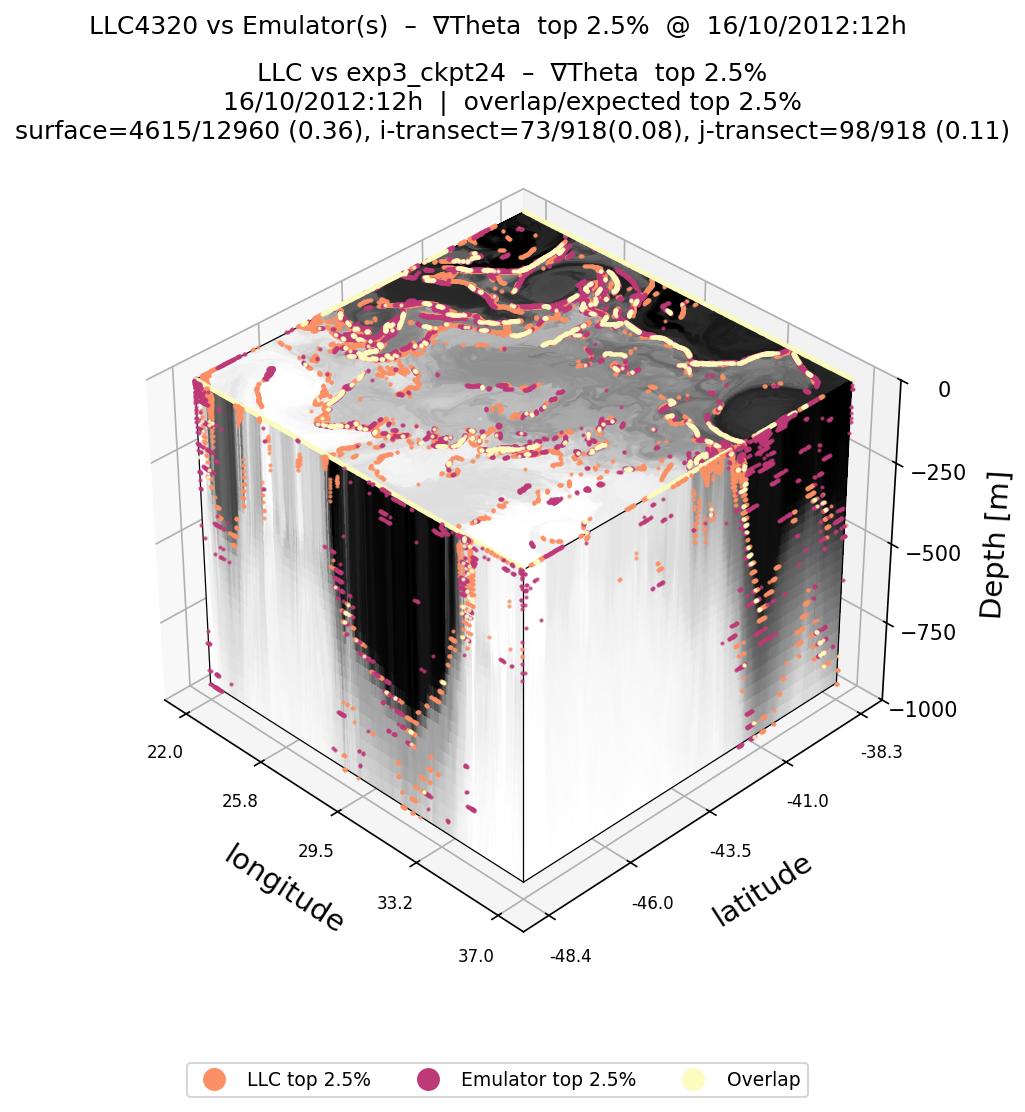

✓  Gradient drift 3-D for Theta


In [7]:
# ============================================================
#  3-D GRADIENT DRIFT FIGURE  –  LLC vs. Emulator(s)
# ============================================================

# ── USER SETTINGS ────────────────────────────────────────────────────────
plot_time_idx  = 15
grad_vars      = ['Theta']
transect_i     = 720
transect_j     = 720
k_max          = 51
bg_stride      = 1
# ─────────────────────────────────────────────────────────────────────────

i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
bs        = bg_stride

time_str = format_time(llc_patch.time.values[plot_time_idx])


# ── Helpers ───────────────────────────────────────────────────────────────

def _pick_dim(dims, candidates, label):
    """Return the first candidate present in dims, with a useful error."""
    for name in candidates:
        if name in dims:
            return name
    raise ValueError(f"Could not find {label} dimension in {tuple(dims)}")


def _get_dim_names(patch, var):
    """
    Detect axis names from the data variable itself.

    Emulator patches can contain Theta on ('k', 'lat', 'lon') while copied
    LLC grid variables add separate ('j', 'i') dimensions to the same Dataset.
    Looking at patch.dims globally can therefore pick the wrong axes.
    """
    dims = patch[var].dims
    k_dim = _pick_dim(dims, ('k', 'Z', 'depth', 'lev'), 'vertical')
    j_dim = _pick_dim(dims, ('j', 'lat', 'y'), 'north-south')
    i_dim = _pick_dim(dims, ('i', 'lon', 'x'), 'east-west')

    return k_dim, j_dim, i_dim


def _get_block_grad(patch, t_idx, var):
    """
    Extract the spatial block at the chosen time.

    1.  Detects dimension names from the requested variable, so isel works
        for both LLC ('j','i') and emulator ('lat','lon') zarr files.
    2.  Calls .transpose(k_dim, j_dim, i_dim) before .values so data[0]
        is always the surface (k = 0) regardless of on-disk axis order.
    3.  Slices rA using rA's own dimensions, which may differ from the
        variable dimensions after LLC grid variables are copied in.
    """
    k_dim, j_dim, i_dim = _get_dim_names(patch, var)

    sub = patch.isel(**{
        'time': t_idx,
        i_dim:  slice(i_0, i_1 + 1),
        j_dim:  slice(j_0, j_1 + 1),
        k_dim:  slice(0, k_max),
    })

    # Guaranteed (k, j, i) regardless of on-disk order
    data = sub[var].transpose(k_dim, j_dim, i_dim).values     # (k, j, i)

    z_da = sub["Z"]
    z_indexers = {}
    if k_dim in z_da.dims:
        z_indexers[k_dim] = slice(0, k_max)
    elif 'k' in z_da.dims:
        z_indexers['k'] = slice(0, k_max)
    z = z_da.isel(**z_indexers).values if z_indexers else z_da.values
    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]
    z = z.ravel()

    n_k, n_j, n_i = data.shape
    i_vals_blk = np.arange(i_0, i_0 + n_i)
    j_vals_blk = np.arange(j_0, j_0 + n_j)

    rA_da = sub['rA']
    rA_j_dim = _pick_dim(rA_da.dims, ('j', 'lat', 'y'), 'rA north-south')
    rA_i_dim = _pick_dim(rA_da.dims, ('i', 'lon', 'x'), 'rA east-west')
    rA_sel = rA_da.isel({
        rA_j_dim: slice(j_0, j_0 + n_j),
        rA_i_dim: slice(i_0, i_0 + n_i),
    })
    for extra_dim in set(rA_sel.dims) - {rA_j_dim, rA_i_dim}:
        rA_sel = rA_sel.isel({extra_dim: 0})
    rA = rA_sel.transpose(rA_j_dim, rA_i_dim).values
    dx = np.sqrt(rA)                                      # (j, i) metres

    return data, z, dx, i_vals_blk, j_vals_blk


def _coord_block_grad(patch, name, n_j, n_i):
    """Grid coordinate block, returned as (j, i)."""
    coord = patch[name]
    j_dim = _pick_dim(coord.dims, ('j', 'lat', 'y'), f'{name} north-south')
    i_dim = _pick_dim(coord.dims, ('i', 'lon', 'x'), f'{name} east-west')
    sel = coord.isel({
        j_dim: slice(j_0, j_0 + n_j),
        i_dim: slice(i_0, i_0 + n_i),
    })
    for extra_dim in set(sel.dims) - {j_dim, i_dim}:
        sel = sel.isel({extra_dim: 0})
    return sel.transpose(j_dim, i_dim).values


def _nice_lon_lat_ticks_grad(coord_2d, axis_vals, axis):
    """Even local-index tick positions with lon/lat labels from XC/YC."""
    idx = np.linspace(0, len(axis_vals) - 1, 5).round().astype(int)
    pos = axis_vals[idx]
    if axis == 'i':
        coord_vals = coord_2d[coord_2d.shape[0] // 2, idx]
    else:
        coord_vals = coord_2d[idx, coord_2d.shape[1] // 2]
    labels = [f'{v:.1f}' for v in coord_vals]
    return pos, labels


def _cell_coords(spacing_1d):
    """Cell-width array → cell-centre physical coordinate array."""
    return np.cumsum(spacing_1d) - spacing_1d / 2


def _compute_surface_gradient_trusted(data, dx):
    """
    Match the trusted surface-gradient calculation in
    prognostic_var_comparison_+gradients.ipynb.

    That notebook uses periodic centered differences via np.roll and divides
    both horizontal directions by sqrt(rA) at each cell.
    """
    surf = data[0]                                      # (j, i)
    d_di = (np.roll(surf, -1, axis=1) - np.roll(surf, 1, axis=1)) / (2 * dx)
    d_dj = (np.roll(surf, -1, axis=0) - np.roll(surf, 1, axis=0)) / (2 * dx)
    return np.sqrt(d_di**2 + d_dj**2)                   # (j, i)


def _compute_face_gradients(data, z_vals, dx):
    """
    In-plane gradient magnitudes for the three visible faces.

    The surface uses the same periodic centered-difference calculation as
    the trusted 2-D gradient notebook, so the high-gradient surface pixels
    are directly comparable.  Vertical walls still use np.gradient so the
    wall edges receive one-sided finite differences instead of wraparound.

    Returns
    -------
    grad_surf  : (j, i)   |∇_h θ|          surface,    ∂/∂i  &  ∂/∂j
    grad_south : (k, i)   |∇_(i,z) θ|      j=j_0 wall, ∂/∂i  &  ∂/∂z
    grad_east  : (k, j)   |∇_(j,z) θ|      i=i_1 wall, ∂/∂j  &  ∂/∂z
    """
    # ── Surface (k=0): trusted 2-D gradient definition ───────────────────
    grad_surf = _compute_surface_gradient_trusted(data, dx)

    # ── South wall (j=j_0): ∂/∂i  and  ∂/∂z ──────────────────────────────
    south       = data[:, 0, :]                         # (k, i)
    i_coords_sw = _cell_coords(dx[0, :])                # (i,) spacing at j=0

    d_di_sw    = np.gradient(south, i_coords_sw, axis=1)
    d_dz_sw    = np.gradient(south, z_vals,      axis=0)
    grad_south = np.sqrt(d_di_sw**2 + d_dz_sw**2)      # (k, i)

    # ── East wall (i=i_1): ∂/∂j  and  ∂/∂z ───────────────────────────────
    east        = data[:, :, -1]                        # (k, j)
    j_coords_ew = _cell_coords(dx[:, -1])               # (j,) spacing at i=i_1

    d_dj_ew   = np.gradient(east, j_coords_ew, axis=1)
    d_dz_ew   = np.gradient(east, z_vals,      axis=0)
    grad_east = np.sqrt(d_dj_ew**2 + d_dz_ew**2)       # (k, j)

    return grad_surf, grad_south, grad_east


def _grad_mask_surface(grad_surf):
    """
    Global 97.5th-percentile mask for the 2-D surface plane.
    The surface is a single horizontal layer, so one global threshold
    is appropriate and matches the original per-k logic applied at k=0.
    """
    thresh = np.nanpercentile(grad_surf, 97.5)
    return grad_surf >= thresh


def _grad_mask_wall(grad_wall):
    """
    Per-depth-level 97.5th-percentile mask for a wall transect.

    Why per-level?  Surface gradients are always the largest in absolute
    terms.  A single global threshold (the previous approach) is dominated
    by k=0, leaving every deeper pixel below the cut-off — producing the
     'all k=0' artefact (Issue 1).

    Computing the threshold independently at each k level mirrors the
    original 2-D gradient mask code (`for k in range(n_depths): …`) and
    ensures thermocline and sub-surface frontal structure is captured.

    grad_wall : (k, n)  where n = i or j
    returns   : bool mask, same shape
    """
    mask = np.zeros_like(grad_wall, dtype=bool)
    for k_idx in range(grad_wall.shape[0]):
        row    = grad_wall[k_idx, :]
        thresh = np.nanpercentile(row, 97.5)
        if np.isnan(thresh):               # all-NaN level (bathymetry) — skip
            continue
        mask[k_idx, :] = row >= thresh
    return mask


def _gray_fc(arr_2d):
    """2-D array → Greys RGBA, contrast-stretched to 2nd–98th percentile."""
    lo = np.nanpercentile(arr_2d, 2)
    hi = np.nanpercentile(arr_2d, 98)
    return plt.cm.Greys(mcolors.Normalize(vmin=lo, vmax=hi, clip=True)(arr_2d))


# ── One figure per variable ───────────────────────────────────────────────
for grad_var in grad_vars:
    print(f"Computing 3-D gradient drift for {grad_var} …")

    n_emulators = len(emulator_info)

    # ── LLC block, gradients, masks ───────────────────────────────────────
    llc_data, z_vals, dx_llc, i_vals, j_vals = _get_block_grad(
        llc_patch, plot_time_idx, grad_var
    )

    llc_surf_grad, llc_south_grad, llc_east_grad = _compute_face_gradients(
        llc_data, z_vals, dx_llc
    )

    llc_mask_surf  = _grad_mask_surface(llc_surf_grad)
    llc_mask_south = _grad_mask_wall(llc_south_grad)
    llc_mask_east  = _grad_mask_wall(llc_east_grad)

    print(f"  LLC  data shape : {llc_data.shape}")
    print(f"  LLC  mask counts: surf={llc_mask_surf.sum():,}, "
          f"south={llc_mask_south.sum():,}, east={llc_mask_east.sum():,}")

    z_top = float(z_vals[0])
    z_bot = float(z_vals[-1])
    z_axis_bot = min(z_bot, -1000.0)
    z_axis_top = max(0.0, z_top)
    z_tick_vals = np.array([0.0, -250.0, -500.0, -750.0, -1000.0])

    xc_block = _coord_block_grad(llc_patch, 'XC', llc_data.shape[1], llc_data.shape[2])
    yc_block = _coord_block_grad(llc_patch, 'YC', llc_data.shape[1], llc_data.shape[2])
    x_tick_pos, x_tick_labels = _nice_lon_lat_ticks_grad(xc_block, i_vals, 'i')
    y_tick_pos, y_tick_labels = _nice_lon_lat_ticks_grad(yc_block, j_vals, 'j')

    fig = plt.figure(figsize=(8 * n_emulators, 7), dpi=150)
    scatter_kw = dict(s=1, alpha=0.75, depthshade=False, rasterized=True, zorder=10)
    drift_colours = {
        'llc_only': '#FC9065',   # orange
        'emu_only': '#BE3977',   # pink
        'overlap':  '#FCFCBE',   # light tan
    }

    for col, (emu_name, emu_key) in enumerate(emulator_info):

        # ── Emulator block, gradients, masks ─────────────────────────────
        emu_data, _, dx_emu, _, _ = _get_block_grad(
            emulator_patches[emu_key], plot_time_idx, grad_var
        )

        assert emu_data.shape == llc_data.shape, (
            f"Shape mismatch: LLC {llc_data.shape} vs {emu_name} {emu_data.shape}"
        )

        emu_surf_grad, emu_south_grad, emu_east_grad = _compute_face_gradients(
            emu_data, z_vals, dx_emu
        )

        emu_mask_surf  = _grad_mask_surface(emu_surf_grad)
        emu_mask_south = _grad_mask_wall(emu_south_grad)
        emu_mask_east  = _grad_mask_wall(emu_east_grad)

        print(f"  {emu_name} mask counts: surf={emu_mask_surf.sum():,}, "
              f"south={emu_mask_south.sum():,}, east={emu_mask_east.sum():,}")

        # ── Three-way breakdown per face ──────────────────────────────────
        surf_overlap   = llc_mask_surf  &  emu_mask_surf
        surf_llc_only  = llc_mask_surf  & ~emu_mask_surf
        surf_emu_only  = emu_mask_surf  & ~llc_mask_surf

        south_overlap  = llc_mask_south &  emu_mask_south
        south_llc_only = llc_mask_south & ~emu_mask_south
        south_emu_only = emu_mask_south & ~llc_mask_south

        east_overlap   = llc_mask_east  &  emu_mask_east
        east_llc_only  = llc_mask_east  & ~emu_mask_east
        east_emu_only  = emu_mask_east  & ~llc_mask_east

        print(f"  Overlap counts: surf={surf_overlap.sum():,}, "
              f"south={south_overlap.sum():,}, east={east_overlap.sum():,}")

        ax = fig.add_subplot(
            1, n_emulators, col + 1,
            projection="3d", computed_zorder=False,
        )

        # Keep colored pixels slightly off the gray planes.  Matplotlib 3-D
        # depth-sorts whole collections, so exactly coplanar surfaces/scatters
        # can hide one another even when scatter is drawn later.
        i_eps = max(1e-6, 0.003 * max(1, i_vals[-1] - i_vals[0]))
        j_eps = max(1e-6, 0.003 * max(1, j_vals[-1] - j_vals[0]))
        z_eps = max(1e-6, 0.003 * max(1.0, abs(z_top - z_bot)))

        # ── Gray background (LLC field) ───────────────────────────────────
        I_bg, J_bg = np.meshgrid(i_vals[::bs], j_vals[::bs])
        ax.plot_surface(
            I_bg, J_bg, np.full_like(I_bg, z_top, dtype=float),
            facecolors=_gray_fc(llc_data[0, ::bs, ::bs]),
            shade=False, rstride=1, cstride=1,
            linewidth=0, antialiased=False, zorder=0,
        )

        I_sw, Z_sw = np.meshgrid(i_vals[::bs], z_vals)
        ax.plot_surface(
            I_sw, np.full_like(I_sw, float(j_0)), Z_sw,
            facecolors=_gray_fc(llc_data[:, 0, ::bs]),
            shade=False, rstride=1, cstride=1,
            linewidth=0, antialiased=False, zorder=0,
        )

        J_ew, Z_ew = np.meshgrid(j_vals[::bs], z_vals)
        ax.plot_surface(
            np.full_like(J_ew, float(i_vals[-1])), J_ew, Z_ew,
            facecolors=_gray_fc(llc_data[:, ::bs, -1]),
            shade=False, rstride=1, cstride=1,
            linewidth=0, antialiased=False, zorder=0,
        )

        # ── Scatter: LLC-only → emulator-only → overlap so overlap sits on top
        # Surface (z = z_top)
        for mask, colour in [
            (surf_llc_only, drift_colours['llc_only']),
            (surf_emu_only, drift_colours['emu_only']),
            (surf_overlap,  drift_colours['overlap']),
        ]:
            jj, ii = np.where(mask)
            if ii.size:
                ax.scatter(
                    i_vals[ii], j_vals[jj],
                    np.full(ii.size, z_top + z_eps),
                    c=colour, **scatter_kw,
                )

        # South wall (y = j_0)
        for mask, colour in [
            (south_llc_only, drift_colours['llc_only']),
            (south_emu_only, drift_colours['emu_only']),
            (south_overlap,  drift_colours['overlap']),
        ]:
            kk, ii = np.where(mask)
            if ii.size:
                ax.scatter(
                    i_vals[ii],
                    np.full(ii.size, float(j_0) - j_eps),
                    z_vals[kk],
                    c=colour, **scatter_kw,
                )

        # East wall (x = i_vals[-1])
        for mask, colour in [
            (east_llc_only, drift_colours['llc_only']),
            (east_emu_only, drift_colours['emu_only']),
            (east_overlap,  drift_colours['overlap']),
        ]:
            kk, jj = np.where(mask)
            if jj.size:
                ax.scatter(
                    np.full(jj.size, float(i_vals[-1]) + i_eps),
                    j_vals[jj],
                    z_vals[kk],
                    c=colour, **scatter_kw,
                )

        # ── Box edges ─────────────────────────────────────────────────────
        ek = dict(color="k", linewidth=0.6)
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[0], j_vals[0]], [z_top, z_top], **ek)
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[-1], j_vals[-1]], [z_top, z_top], **ek)
        ax.plot([i_vals[0], i_vals[0]], [j_vals[0], j_vals[-1]], [z_top, z_top], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[-1]], [z_top, z_top], **ek)
        ax.plot([i_vals[0], i_vals[-1]], [j_vals[0], j_vals[0]], [z_bot, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[-1]], [z_bot, z_bot], **ek)
        ax.plot([i_vals[0], i_vals[0]], [j_vals[0], j_vals[0]], [z_top, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[0], j_vals[0]], [z_top, z_bot], **ek)
        ax.plot([i_vals[-1], i_vals[-1]], [j_vals[-1], j_vals[-1]], [z_top, z_bot], **ek)

        surf_pix  = int(0.025 * surf_overlap.size)
        south_pix = int(0.025 * south_overlap.size)  # fixed-j wall, varies over (k, i)
        east_pix  = int(0.025 * east_overlap.size)   # fixed-i wall, varies over (k, j)

        ax.view_init(elev=35, azim=-45)
        ax.set_xticks(x_tick_pos)
        ax.set_xticklabels(x_tick_labels, fontsize=8)
        ax.set_yticks(y_tick_pos)
        ax.set_yticklabels(y_tick_labels, fontsize=8)
        ax.set_zlim(z_axis_bot, z_axis_top)
        ax.set_zticks(z_tick_vals)
        ax.set_xlabel("longitude", labelpad=8, fontsize=14)
        ax.set_ylabel("latitude", labelpad=8, fontsize=14)
        ax.set_zlabel("Depth [m]",  labelpad=8, fontsize=14)
        ax.set_title(
            f"LLC vs {emu_name}  –  ∇{grad_var}  top 2.5%\n"
            f"{time_str}  |  overlap/expected top 2.5%\n"
            f"surface={int(surf_overlap.sum())}/{surf_pix} ({np.round(surf_overlap.sum()/surf_pix,2)}), "
            f"i-transect={int(south_overlap.sum())}/{south_pix}({np.round(south_overlap.sum()/south_pix,2)}), "
            f"j-transect={int(east_overlap.sum())}/{east_pix} ({np.round(east_overlap.sum()/east_pix,2)})",
            fontsize=12,
        )

    # ── Shared legend ──────────────────────────────────────────────────────
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=drift_colours['llc_only'],
               markersize=12, label='LLC top 2.5%'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=drift_colours['emu_only'],
               markersize=12, label='Emulator top 2.5%'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=drift_colours['overlap'],
               markersize=12, label='Overlap'),
    ]
    fig.legend(
        handles=legend_elements,
        loc='lower center', ncol=3, fontsize=9,
        bbox_to_anchor=(0.5, -0.03),
    )

    plt.suptitle(
        f"LLC4320 vs Emulator(s)  –  ∇{grad_var}  top 2.5%  @  {time_str}",
        fontsize=12, y=1.01,
    )

    plt.tight_layout()
    plt.show()
    print(f"✓  Gradient drift 3-D for {grad_var}")

In [ ]:
# ============================================================
#  3-D COMPOSITE FIGURE
#  Surface:      Theta  (magma)  – shared norm across sources
#  South wall:   KE     (plasma)      – constant-j transect
#  East wall:    B      (viridis)     – constant-i transect
# ============================================================

# ── USER SETTINGS ─────────────────────────────────────────────────────────
plot_time_idx = 15
transect_i    = 720    # east-wall i;   surface/south-wall span i = 0 … transect_i
transect_j    = 720    # south-wall j;  surface/east-wall  span j = 0 … transect_j
k_max         = 51
plot_stride   = 1
# ──────────────────────────────────────────────────────────────────────────

G    = 9.81
rho0 = 1025.0

i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
s         = plot_stride

i_vals = None  # filled from extracted block shapes below
j_vals = None

cmap_theta = plt.cm.magma
cmap_B     = plt.cm.viridis
cmap_KE    = plt.cm.plasma

sources  = [('LLC', llc_patch)] + [
    (name, emulator_patches[key]) for name, key in emulator_info
]
n_cols   = len(sources)
time_str = format_time(llc_patch.time.values[plot_time_idx])


# ── Dimension detection ───────────────────────────────────────────────────
def _pick_dim(dims, candidates, label):
    for name in candidates:
        if name in dims:
            return name
    raise ValueError(f"Could not find {label} dimension in {tuple(dims)}")


def _dims(patch, var):
    """(k_dim, j_dim, i_dim) for a specific variable, including staggered axes."""
    d = patch[var].dims
    kd = _pick_dim(d, ('k', 'Z', 'depth', 'lev'), 'vertical')
    jd = _pick_dim(d, ('j', 'j_g', 'lat', 'y'), 'north-south')
    id_ = _pick_dim(d, ('i', 'i_g', 'lon', 'x'), 'east-west')
    return kd, jd, id_


# ── Efficient per-face extractors ─────────────────────────────────────────
# Each function reads only the slice needed — no full-volume arrays allocated.

def _surface_theta(patch, t_idx):
    """Theta at k=0, full j×i surface  →  (j, i)."""
    kd, jd, id_ = _dims(patch, 'Theta')
    sub = patch.isel(**{
        'time': t_idx,
        kd    : 0,
        jd    : slice(j_0, j_1 + 1),
        id_   : slice(i_0, i_1 + 1),
    })
    return sub['Theta'].transpose(jd, id_).values          # (j, i)


def _south_wall_KE(patch, t_idx):
    """KE at constant j=j_0 south wall  →  (k, i)."""
    kd_u, jd_u, id_u = _dims(patch, 'U')
    sub_u = patch['U'].isel({
        'time': t_idx,
        kd_u  : slice(0, k_max),
        jd_u  : j_0,
        id_u  : slice(i_0, i_1 + 1),
    })
    U = sub_u.transpose(kd_u, id_u).values                 # (k, i-like)

    kd_v, jd_v, id_v = _dims(patch, 'V')
    sub_v = patch['V'].isel({
        'time': t_idx,
        kd_v  : slice(0, k_max),
        jd_v  : j_0,
        id_v  : slice(i_0, i_1 + 1),
    })
    V = sub_v.transpose(kd_v, id_v).values                 # (k, i-like)

    n_k = min(U.shape[0], V.shape[0])
    n_i = min(U.shape[1], V.shape[1])
    U = U[:n_k, :n_i]
    V = V[:n_k, :n_i]
    return 0.5 * (U**2 + V**2)                             # (k, i)


def _east_wall_B(patch, t_idx):
    """
    Buoyancy at constant i=i_1 east wall  →  (k, j).
    Selects the i-block first then takes isel(-1) so the call is
    safe even when i_1 equals the patch size (no out-of-bounds error).
    """
    kd, jd, id_ = _dims(patch, 'Salt')
    sub = patch.isel(**{
        'time': t_idx,
        kd    : slice(0, k_max),
        jd    : slice(j_0, j_1 + 1),
        id_   : slice(i_0, i_1 + 1),
    }).isel(**{id_: -1})                                   # last i in block
    Salt  = sub['Salt'].transpose(kd, jd).values           # (k, j)
    kd_t, jd_t, id_t = _dims(patch, 'Theta')
    theta_sub = patch['Theta'].isel({
        'time': t_idx,
        kd_t  : slice(0, k_max),
        jd_t  : slice(j_0, j_1 + 1),
        id_t  : slice(i_0, i_1 + 1),
    }).isel(**{id_t: -1})
    Theta = theta_sub.transpose(kd_t, jd_t).values         # (k, j)
    n_k = min(Salt.shape[0], Theta.shape[0])
    n_j = min(Salt.shape[1], Theta.shape[1])
    Salt = Salt[:n_k, :n_j]
    Theta = Theta[:n_k, :n_j]
    sigma0 = jmd95numba.rho(Salt, Theta, 0) - rho0
    return -G * sigma0 / rho0                              # (k, j)


def _get_z(patch, t_idx):
    """Depth coordinate vector  →  (k,)."""
    kd = _pick_dim(patch['Z'].dims, ('k', 'Z', 'depth', 'lev'), 'Z vertical')
    sub = patch.isel(**{'time': t_idx, kd: slice(0, k_max)})
    z = sub['Z'].values
    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]
    return z.ravel()


def _coord_block(patch, name, n_j, n_i):
    """Grid coordinate block, returned as (j, i) when available."""
    coord = patch[name]
    jd = _pick_dim(coord.dims, ('j', 'lat', 'y'), f'{name} north-south')
    id_ = _pick_dim(coord.dims, ('i', 'lon', 'x'), f'{name} east-west')
    sel = coord.isel({
        jd: slice(j_0, j_0 + n_j),
        id_: slice(i_0, i_0 + n_i),
    })
    for extra_dim in set(sel.dims) - {jd, id_}:
        sel = sel.isel({extra_dim: 0})
    return sel.transpose(jd, id_).values


def _nice_lon_lat_ticks(coord_2d, axis_vals, axis):
    """Even local-index tick positions with lon/lat labels from XC/YC."""
    n_ticks = 5
    idx = np.linspace(0, len(axis_vals) - 1, n_ticks).round().astype(int)
    pos = axis_vals[idx]
    if axis == 'i':
        coord_vals = coord_2d[coord_2d.shape[0] // 2, idx]
    else:
        coord_vals = coord_2d[idx, coord_2d.shape[1] // 2]
    labels = [f'{v:.1f}' for v in coord_vals]
    return pos, labels


# ── Fetch all data blocks ─────────────────────────────────────────────────
print("Extracting face data …")
blocks = {}
for label, patch in sources:
    blocks[label] = {
        'theta_surf': _surface_theta(patch, plot_time_idx),
        'KE_south'  : _south_wall_KE(patch, plot_time_idx),
        'B_east'    : _east_wall_B(  patch, plot_time_idx),
    }
    print(f"  ✓  {label}  |  "
          f"θ {blocks[label]['theta_surf'].shape}  "
          f"KE {blocks[label]['KE_south'].shape}  "
          f"B {blocks[label]['B_east'].shape}")

n_j, n_i = blocks['LLC']['theta_surf'].shape
i_vals = np.arange(i_0, i_0 + n_i)
j_vals = np.arange(j_0, j_0 + n_j)
i_plot_1 = float(i_vals[-1])
j_plot_1 = float(j_vals[-1])
xc_block = _coord_block(llc_patch, 'XC', n_j, n_i)
yc_block = _coord_block(llc_patch, 'YC', n_j, n_i)
x_tick_pos, x_tick_labels = _nice_lon_lat_ticks(xc_block, i_vals, 'i')
y_tick_pos, y_tick_labels = _nice_lon_lat_ticks(yc_block, j_vals, 'j')

z_vals = _get_z(llc_patch, plot_time_idx)
z_top  = float(z_vals[0])
z_bot  = float(z_vals[-1])
z_axis_bot = min(z_bot, -1000.0)
z_axis_top = max(0.0, z_top)
z_tick_vals = np.array([0.0, -250.0, -500.0, -750.0, -1000.0])


# ── Shared colour norms (per face, pooled across all sources) ─────────────
def _norm(key):
    """1st–99th percentile norm over all sources for one face key."""
    vals = np.concatenate([blocks[lbl][key].ravel() for lbl, _ in sources])
    vals = vals[np.isfinite(vals)]
    return mcolors.Normalize(
        vmin=float(np.nanpercentile(vals, 1)),
        vmax=float(np.nanpercentile(vals, 99)),
    )

norm_theta = _norm('theta_surf')
norm_KE    = _norm('KE_south')
norm_B     = _norm('B_east')

# Default-arg trick freezes each norm/cmap at definition time
to_fc_theta = lambda a, _n=norm_theta, _c=cmap_theta: _c(_n(a))
to_fc_KE    = lambda a, _n=norm_KE,    _c=cmap_KE:    _c(_n(a))
to_fc_B     = lambda a, _n=norm_B,     _c=cmap_B:     _c(_n(a))


# ── Figure layout ─────────────────────────────────────────────────────────
#
#   [B cbar]  |  [3-D: LLC]  [3-D: Emu1]  …  |  [KE cbar]
#                  [Θ cbar below LLC]
#
FIG_L, FIG_R = 0.10, 0.90
FIG_B, FIG_T = 0.15, 0.92
sp_w         = (FIG_R - FIG_L) / n_cols   # per-column width in figure coords
CB_W         = 0.018                       # colorbar strip width

fig = plt.figure(figsize=(7 * n_cols + 2, 9), dpi=150)
fig.subplots_adjust(left=FIG_L, right=FIG_R,
                    bottom=FIG_B, top=FIG_T, wspace=0.25)

axes_3d = [fig.add_subplot(1, n_cols, c + 1, projection='3d')
           for c in range(n_cols)]


# ── Plot each column ──────────────────────────────────────────────────────
for col, (label, _) in enumerate(sources):
    ax = axes_3d[col]
    b  = blocks[label]

    # ① Surface (k=0) – Theta ────────────────────────────────────────────
    I_s, J_s = np.meshgrid(i_vals[::s], j_vals[::s])
    ax.plot_surface(
        I_s, J_s, np.full_like(I_s, z_top, dtype=float),
        facecolors=to_fc_theta(b['theta_surf'][::s, ::s]),
        shade=False, rstride=1, cstride=1,
    )

    # ② South wall (j=j_0) – KE ──────────────────────────────────────────
    I_j, Z_j = np.meshgrid(i_vals[::s], z_vals)
    ax.plot_surface(
        I_j, np.full_like(I_j, float(j_0)), Z_j,
        facecolors=to_fc_KE(b['KE_south'][:, ::s]),
        shade=False, rstride=1, cstride=1,
    )

    # ③ East wall (i=i_1) – B ────────────────────────────────────────────
    J_i, Z_i = np.meshgrid(j_vals[::s], z_vals)
    ax.plot_surface(
        np.full_like(J_i, i_plot_1), J_i, Z_i,
        facecolors=to_fc_B(b['B_east'][:, ::s]),
        shade=False, rstride=1, cstride=1,
    )

    # ── Box edges ─────────────────────────────────────────────────────────
    ek = dict(color='k', linewidth=0.6)
    ax.plot([i_0, i_plot_1], [j_0, j_0], [z_top, z_top], **ek)
    ax.plot([i_0, i_plot_1], [j_plot_1, j_plot_1], [z_top, z_top], **ek)
    ax.plot([i_0, i_0], [j_0, j_plot_1], [z_top, z_top], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_0, j_plot_1], [z_top, z_top], **ek)
    ax.plot([i_0, i_plot_1], [j_0, j_0], [z_bot, z_bot], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_0, j_plot_1], [z_bot, z_bot], **ek)
    ax.plot([i_0, i_0], [j_0, j_0], [z_top, z_bot], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_0, j_0], [z_top, z_bot], **ek)
    ax.plot([i_plot_1, i_plot_1], [j_plot_1, j_plot_1], [z_top, z_bot], **ek)

    ax.view_init(elev=35, azim=-45)
    ax.set_xticks(x_tick_pos)
    ax.set_xticklabels(x_tick_labels, fontsize=8)
    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(y_tick_labels, fontsize=8)
    ax.set_zlim(z_axis_bot, z_axis_top)
    ax.set_zticks(z_tick_vals)
    ax.set_xlabel('longitude', labelpad=8, fontsize=12)
    ax.set_ylabel('latitude', labelpad=8, fontsize=12)
    ax.set_zlabel('Depth [m]',  labelpad=8, fontsize=12)
    ax.set_title(f'{label}\n{time_str}', fontsize=12)


# ── Colorbars ─────────────────────────────────────────────────────────────
CB_LEN = 0.75 * (FIG_T - FIG_B - 0.14)    # shared visual length for all cbars
CB_THICK = CB_W
cb_v_b = FIG_B + 0.5 * ((FIG_T - FIG_B) - CB_LEN)
cb_theta_y = 0.5 * 0.05 + 0.5 * FIG_B     # halfway from old position to cube bottom
cb_theta_x = 0.5 - 0.5 * CB_LEN

# KE – far left, ticks/label on left
ax_cb_KE = fig.add_axes([FIG_L - 0.035, cb_v_b, CB_THICK, CB_LEN])
cb_KE = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_KE, cmap=cmap_KE),
    cax=ax_cb_KE,
    orientation='vertical',
)
cb_KE.set_label('Transect Kinetic Energy per unit mass [m² s⁻²]', fontsize=12)

ax_cb_KE.yaxis.set_ticks_position('left')
ax_cb_KE.yaxis.set_label_position('left')


# B – far right, ticks/label on right
ax_cb_B = fig.add_axes([1.0 - 0.015 - CB_THICK, cb_v_b, CB_THICK, CB_LEN])
cb_B = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_B, cmap=cmap_B),
    cax=ax_cb_B,
    orientation='vertical',
)
cb_B.set_label('Transect Buoyancy [m s⁻²]', fontsize=12)

ax_cb_B.yaxis.set_ticks_position('right')
ax_cb_B.yaxis.set_label_position('right')

# Theta – horizontal, centred under the full figure
ax_cb_theta = fig.add_axes([cb_theta_x, cb_theta_y, CB_LEN, CB_THICK])
cb_theta    = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_theta, cmap=cmap_theta),
    cax=ax_cb_theta, orientation='horizontal',
)
cb_theta.set_label('Surface Potential Temperature  [°C]', fontsize=12)

# plt.suptitle(
#     f'LLC4320 vs Emulator(s)  –  Composite 3-D  @  {time_str}',
#     fontsize=12, y=0.97,
# )

plt.show()

In [ ]:
for patch_name, patch in all_patches.items():
    print(f"Computing KE for {patch_name}...")
    U = patch['U'].values
    V = patch['V'].values
    KE = 0.5 * (U**2 + V**2)
    patch['KE'] = (('time', 'k', 'j', 'i'), KE)
    print(f"  ✓ KE shape: {KE.shape}")
print("Done.")

Computing KE for llc...


  ✓ KE shape: (16, 51, 720, 720)
Computing KE for emulator_2...
  ✓ KE shape: (16, 51, 720, 720)
Done.


In [5]:
G = 9.81
rho0 = 1025 

for patch_name, patch in all_patches.items():
    print(f"Computing Buoyancy for {patch_name}...")
    Salt = patch['Salt'].values
    Theta = patch['Theta'].values
    sigma0 = jmd95numba.rho(Salt, Theta, 0) - rho0
    B = -G * sigma0 / rho0
    patch['B'] = (('time', 'k', 'j', 'i'), B)
    print(f"  ✓ B shape: {B.shape}")
print("Done.")

Computing Buoyancy for llc...
  ✓ B shape: (16, 51, 720, 720)
Computing Buoyancy for emulator_2...
  ✓ B shape: (16, 51, 720, 720)
Done.


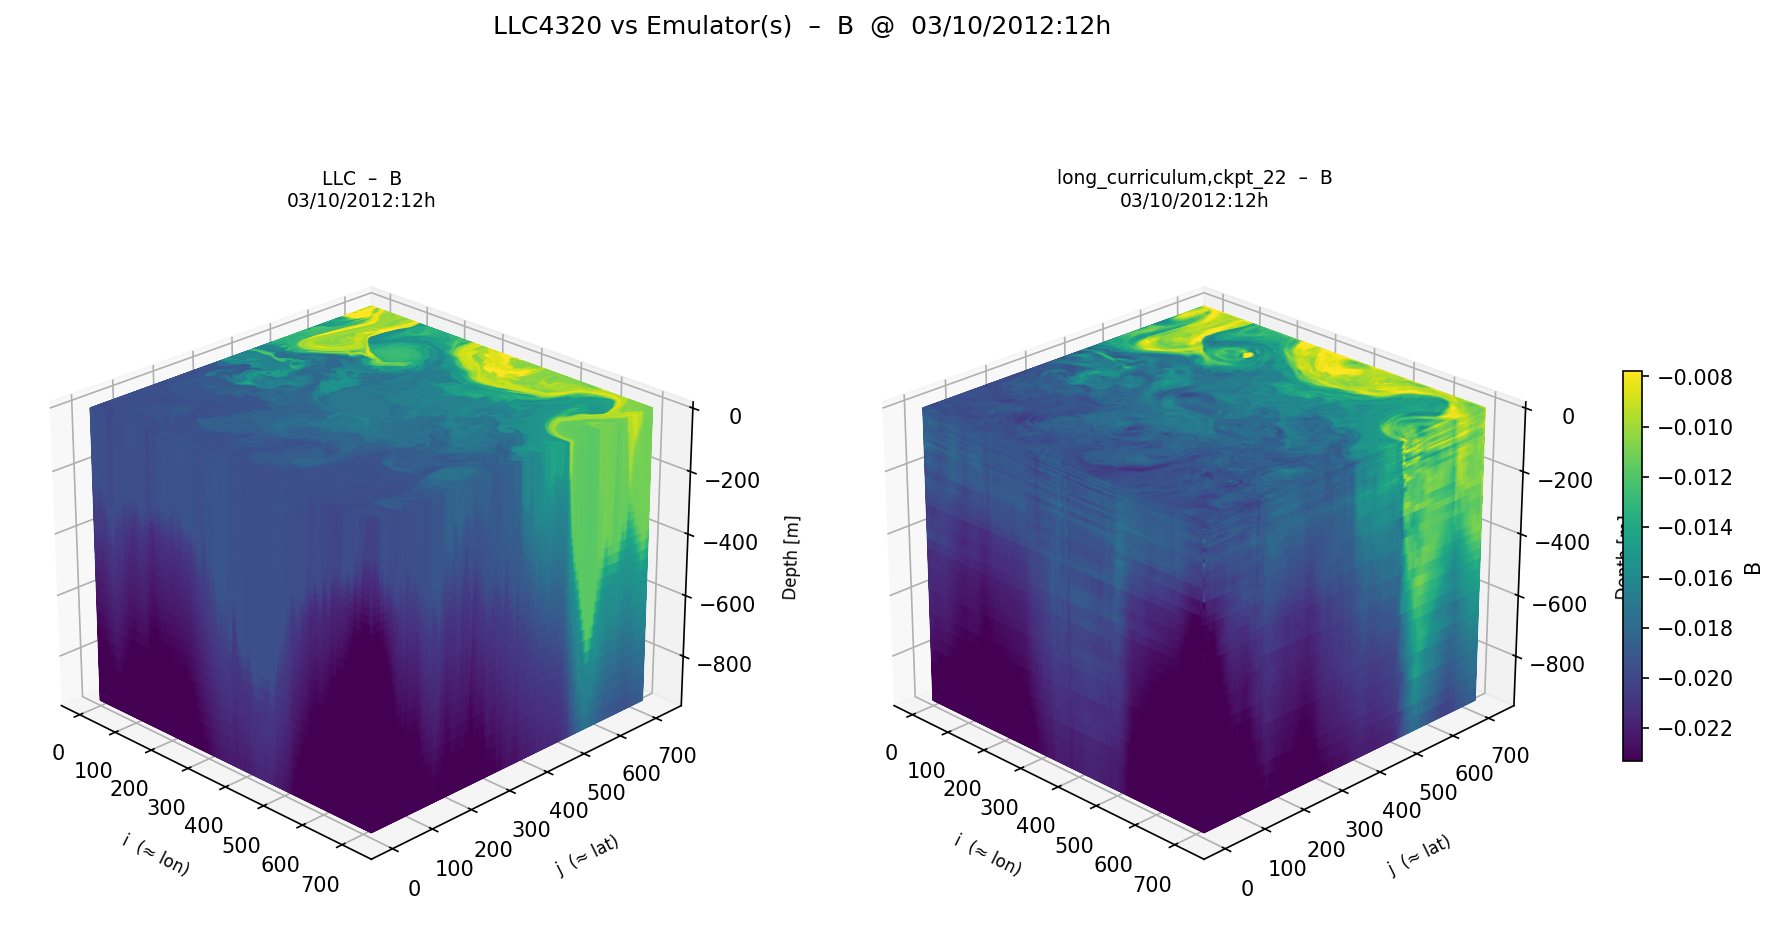

In [ ]:
# ============================================================
#  3-D COMPARISON PLOT  –  LLC vs. Emulator(s)
# ============================================================

# ── USER SETTINGS ────────────────────────────────────────────────────────
plot_time_idx  = 15          # index into the synchronised time axis
plot_vars      = ['B']       # variables to plot (one figure per variable)
transect_i     = 720         # east-wall i-slice  (surface spans i = 0 … transect_i)
transect_j     = 720         # south-wall j-slice (surface spans j = 0 … transect_j)
k_max          = 51          # depth levels to include  (k = 0 … k_max − 1)
plot_stride    = 1           # horizontal downsampling stride (1 = full-res, slow)
# ─────────────────────────────────────────────────────────────────────────

# ── Colour map ───────────────────────────────────────────────────────────
cmap_3d =  plt.cm.viridis  #mcolors.LinearSegmentedColormap.from_list(
#     "viridis_dark_3qrt",
#     plt.cm.viridis(np.linspace(0, 0.75, 256)),
# )

# ── Domain bounds derived from transect selections ───────────────────────
i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
s = plot_stride

# ── Coordinate arrays ────────────────────────────────────────────────────
i_vals = np.arange(i_0, i_1 + 1)
j_vals = np.arange(j_0, j_1 + 1)

# ── Ordered source list: LLC first, then emulators ───────────────────────
sources = [('LLC', llc_patch)] + [
    (name, emulator_patches[key]) for name, key in emulator_info
]
n_cols = len(sources)

# ── Helper: extract the 3-D block from any patch ─────────────────────────
def _get_block(patch, t_idx, var):
    sub = patch.isel(
        time=t_idx,
        i=slice(i_0, i_1 + 1),
        j=slice(j_0, j_1 + 1),
        k=slice(0, k_max),
    )

    data = sub[var].values      # expected shape: (k, j, i)
    z = sub["Z"].values

    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]

    return data, z.ravel()


# ── Helper: return only arrays that are actually plotted ─────────────────
def _get_plotted_faces(var):
    """
    Extract only the values that are sent to plot_surface.

    Returns:
        top surface: var[0, ::s, ::s]
        south wall: var[:, 0, ::s]
        east wall:  var[:, ::s, -1]
    """
    return [
        var[0, ::s, ::s],    # surface face, k = 0
        var[:, 0, ::s],      # south wall, j = 0
        var[:, ::s, -1],     # east wall, i = i_1
    ]


# ── Time label ───────────────────────────────────────────────────────────
time_str = format_time(llc_patch.time.values[plot_time_idx])

# os.makedirs('figs/3d_comparison', exist_ok=True)

# ── One figure per variable ──────────────────────────────────────────────
for plot_var in plot_vars:

    # Pre-fetch all blocks
    blocks = {
        label: _get_block(patch, plot_time_idx, plot_var)
        for label, patch in sources
    }

    # ---------------------------------------------------------------------
    # Colour limits based ONLY on values that are actually plotted:
    #   ① surface face
    #   ② south wall
    #   ③ east wall
    #
    # This excludes the unplotted interior volume.
    # ---------------------------------------------------------------------
    plotted_values = []

    for var, _ in blocks.values():
        for face in _get_plotted_faces(var):
            plotted_values.append(face.ravel())

    plotted_values = np.concatenate(plotted_values)
    plotted_values = plotted_values[np.isfinite(plotted_values)]

    vmin = float(np.nanpercentile(plotted_values, 1))
    vmax = float(np.nanpercentile(plotted_values, 99))

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def to_fc(arr, _n=norm, _c=cmap_3d):
        """Data array → RGBA face-colour array."""
        return _c(_n(arr))

    # ── Figure: 1 row × n_cols subplots ──────────────────────────────────
    fig = plt.figure(figsize=(7 * n_cols, 7), dpi=150)

    for col, (label, _) in enumerate(sources):
        var, z_vals = blocks[label]

        z_top = float(z_vals[0])
        z_bot = float(z_vals[-1])

        ax = fig.add_subplot(1, n_cols, col + 1, projection="3d")

        # ① Surface face  (k = 0) -----------------------------------------
        I_s, J_s = np.meshgrid(i_vals[::s], j_vals[::s])

        ax.plot_surface(
            I_s,
            J_s,
            np.full_like(I_s, z_top, dtype=float),
            facecolors=to_fc(var[0, ::s, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ② South wall  (j = 0) -------------------------------------------
        I_j, Z_j = np.meshgrid(i_vals[::s], z_vals)

        ax.plot_surface(
            I_j,
            np.full_like(I_j, float(j_0)),
            Z_j,
            facecolors=to_fc(var[:, 0, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ③ East wall  (i = transect_i) -----------------------------------
        J_i, Z_i = np.meshgrid(j_vals[::s], z_vals)

        ax.plot_surface(
            np.full_like(J_i, float(i_1)),
            J_i,
            Z_i,
            facecolors=to_fc(var[:, ::s, -1]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ── Box outline edges ─────────────────────────────────────────────
        ek = dict(color="k", linewidth=0.6)

        # Top rectangle
        ax.plot([i_0, i_1], [j_0, j_0], [z_top, z_top], **ek)
        ax.plot([i_0, i_1], [j_1, j_1], [z_top, z_top], **ek)
        ax.plot([i_0, i_0], [j_0, j_1], [z_top, z_top], **ek)
        ax.plot([i_1, i_1], [j_0, j_1], [z_top, z_top], **ek)

        # Bottom edges of the two visible walls
        ax.plot([i_0, i_1], [j_0, j_0], [z_bot, z_bot], **ek)
        ax.plot([i_1, i_1], [j_0, j_1], [z_bot, z_bot], **ek)

        # Vertical edges
        ax.plot([i_0, i_0], [j_0, j_0], [z_top, z_bot], **ek)
        ax.plot([i_1, i_1], [j_0, j_0], [z_top, z_bot], **ek)
        ax.plot([i_1, i_1], [j_1, j_1], [z_top, z_bot], **ek)

        ax.view_init(elev=35, azim=-45)

        ax.set_xlabel("i  (≈ lon)", labelpad=8, fontsize=8)
        ax.set_ylabel("j  (≈ lat)", labelpad=8, fontsize=8)
        ax.set_zlabel("Depth [m]", labelpad=8, fontsize=8)

        ax.set_title(
            f"{label}  –  {plot_var}\n{time_str}",
            fontsize=9,
        )

    # ── Single shared colour bar for all panels ──────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap_3d, norm=norm)
    sm.set_array([])

    cbar_label = "Θ  [°C]" if plot_var == "Theta" else plot_var

    fig.colorbar(
        sm,
        ax=fig.axes,
        fraction=0.012,
        pad=0.05,
        shrink=0.55,
        label=cbar_label,
    )

    plt.suptitle(
        f"LLC4320 vs Emulator(s)  –  {plot_var}  @  {time_str}",
        fontsize=12,
        y=1.02,
    )

    out_path = f"figs/3d_comparison/3d_{plot_var}_{plot_time_idx:03d}.png"

    # plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    # plt.close()
    # print(f"✓  {plot_var}  →  {out_path}")

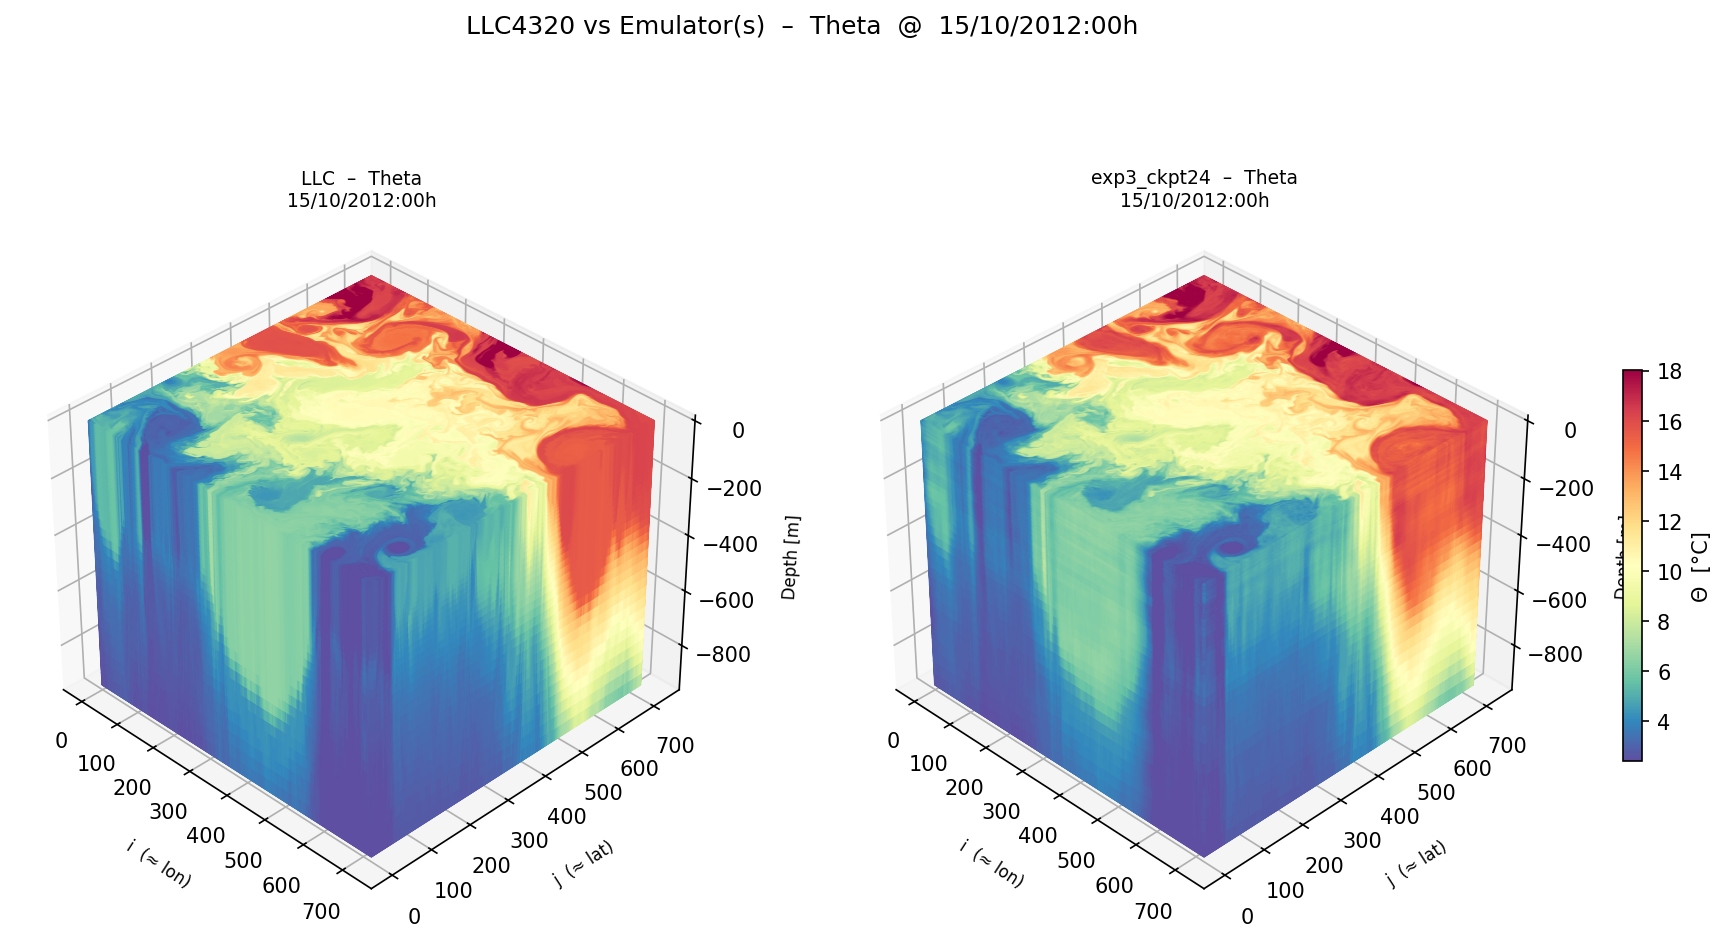

In [ ]:
# ============================================================
#  3-D COMPARISON PLOT  –  LLC vs. Emulator(s)
# ============================================================

# ── USER SETTINGS ────────────────────────────────────────────────────────
plot_time_idx  = 3           # index into the synchronised time axis
plot_vars      = ['Theta']   # variables to plot (one figure per variable)
transect_i     = 720         # east-wall i-slice  (surface spans i = 0 … transect_i)
transect_j     = 720         # south-wall j-slice (surface spans j = 0 … transect_j)
k_max          = 51          # depth levels to include  (k = 0 … k_max − 1)
plot_stride    = 1           # horizontal downsampling stride (1 = full-res, slow)
# ─────────────────────────────────────────────────────────────────────────

# ── Colour map ───────────────────────────────────────────────────────────
cmap_3d = plt.cm.magma

# ── Domain bounds derived from transect selections ───────────────────────
i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
s = plot_stride

# ── Coordinate arrays ────────────────────────────────────────────────────
i_vals = np.arange(i_0, i_1 + 1)
j_vals = np.arange(j_0, j_1 + 1)

# ── Ordered source list: LLC first, then emulators ───────────────────────
sources = [('LLC', llc_patch)] + [
    (name, emulator_patches[key]) for name, key in emulator_info
]
n_cols = len(sources)

# ── Helper: extract the 3-D block from any patch ─────────────────────────
def _get_block(patch, t_idx, var):
    sub = patch.isel(
        time=t_idx,
        i=slice(i_0, i_1 + 1),
        j=slice(j_0, j_1 + 1),
        k=slice(0, k_max),
    )

    data = sub[var].values      # expected shape: (k, j, i)
    z = sub["Z"].values

    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]

    return data, z.ravel()


# ── Helper: return only arrays that are actually plotted ─────────────────
def _get_plotted_faces(var):
    """
    Extract only the values that are sent to plot_surface.

    Returns:
        top surface: var[0, ::s, ::s]
        south wall: var[:, 0, ::s]
        east wall:  var[:, ::s, -1]
    """
    return [
        var[0, ::s, ::s],    # surface face, k = 0
        var[:, 0, ::s],      # south wall, j = 0
        var[:, ::s, -1],     # east wall, i = i_1
    ]


# ── Time label ───────────────────────────────────────────────────────────
time_str = format_time(llc_patch.time.values[plot_time_idx])

# os.makedirs('figs/3d_comparison', exist_ok=True)

# ── One figure per variable ──────────────────────────────────────────────
for plot_var in plot_vars:

    # Pre-fetch all blocks
    blocks = {
        label: _get_block(patch, plot_time_idx, plot_var)
        for label, patch in sources
    }

    # ---------------------------------------------------------------------
    # Colour limits based ONLY on values that are actually plotted:
    #   ① surface face
    #   ② south wall
    #   ③ east wall
    #
    # This excludes the unplotted interior volume.
    # ---------------------------------------------------------------------
    plotted_values = []

    for var, _ in blocks.values():
        for face in _get_plotted_faces(var):
            plotted_values.append(face.ravel())

    plotted_values = np.concatenate(plotted_values)
    plotted_values = plotted_values[np.isfinite(plotted_values)]

    vmin = float(np.nanpercentile(plotted_values, 1))
    vmax = float(np.nanpercentile(plotted_values, 99))

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def to_fc(arr, _n=norm, _c=cmap_3d):
        """Data array → RGBA face-colour array."""
        return _c(_n(arr))

    # ── Figure: 1 row × n_cols subplots ──────────────────────────────────
    fig = plt.figure(figsize=(7 * n_cols, 7), dpi=150)

    for col, (label, _) in enumerate(sources):
        var, z_vals = blocks[label]

        z_top = float(z_vals[0])
        z_bot = float(z_vals[-1])

        ax = fig.add_subplot(1, n_cols, col + 1, projection="3d")

        # ① Surface face  (k = 0) -----------------------------------------
        I_s, J_s = np.meshgrid(i_vals[::s], j_vals[::s])

        ax.plot_surface(
            I_s,
            J_s,
            np.full_like(I_s, z_top, dtype=float),
            facecolors=to_fc(var[0, ::s, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ② South wall  (j = 0) -------------------------------------------
        I_j, Z_j = np.meshgrid(i_vals[::s], z_vals)

        ax.plot_surface(
            I_j,
            np.full_like(I_j, float(j_0)),
            Z_j,
            facecolors=to_fc(var[:, 0, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ③ East wall  (i = transect_i) -----------------------------------
        J_i, Z_i = np.meshgrid(j_vals[::s], z_vals)

        ax.plot_surface(
            np.full_like(J_i, float(i_1)),
            J_i,
            Z_i,
            facecolors=to_fc(var[:, ::s, -1]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ── Box outline edges ─────────────────────────────────────────────
        ek = dict(color="k", linewidth=0.6)

        # Top rectangle
        ax.plot([i_0, i_1], [j_0, j_0], [z_top, z_top], **ek)
        ax.plot([i_0, i_1], [j_1, j_1], [z_top, z_top], **ek)
        ax.plot([i_0, i_0], [j_0, j_1], [z_top, z_top], **ek)
        ax.plot([i_1, i_1], [j_0, j_1], [z_top, z_top], **ek)

        # Bottom edges of the two visible walls
        ax.plot([i_0, i_1], [j_0, j_0], [z_bot, z_bot], **ek)
        ax.plot([i_1, i_1], [j_0, j_1], [z_bot, z_bot], **ek)

        # Vertical edges
        ax.plot([i_0, i_0], [j_0, j_0], [z_top, z_bot], **ek)
        ax.plot([i_1, i_1], [j_0, j_0], [z_top, z_bot], **ek)
        ax.plot([i_1, i_1], [j_1, j_1], [z_top, z_bot], **ek)

        ax.view_init(elev=35, azim=-45)

        ax.set_xlabel("i  (≈ lon)", labelpad=8, fontsize=8)
        ax.set_ylabel("j  (≈ lat)", labelpad=8, fontsize=8)
        ax.set_zlabel("Depth [m]", labelpad=8, fontsize=8)

        ax.set_title(
            f"{label}  –  {plot_var}\n{time_str}",
            fontsize=9,
        )

    # ── Single shared colour bar for all panels ──────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap_3d, norm=norm)
    sm.set_array([])

    cbar_label = "Θ  [°C]" if plot_var == "Theta" else plot_var

    fig.colorbar(
        sm,
        ax=fig.axes,
        fraction=0.012,
        pad=0.05,
        shrink=0.55,
        label=cbar_label,
    )

    plt.suptitle(
        f"LLC4320 vs Emulator(s)  –  {plot_var}  @  {time_str}",
        fontsize=12,
        y=1.02,
    )

    out_path = f"figs/3d_comparison/3d_{plot_var}_{plot_time_idx:03d}.png"

    # plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    # plt.close()
    # print(f"✓  {plot_var}  →  {out_path}")

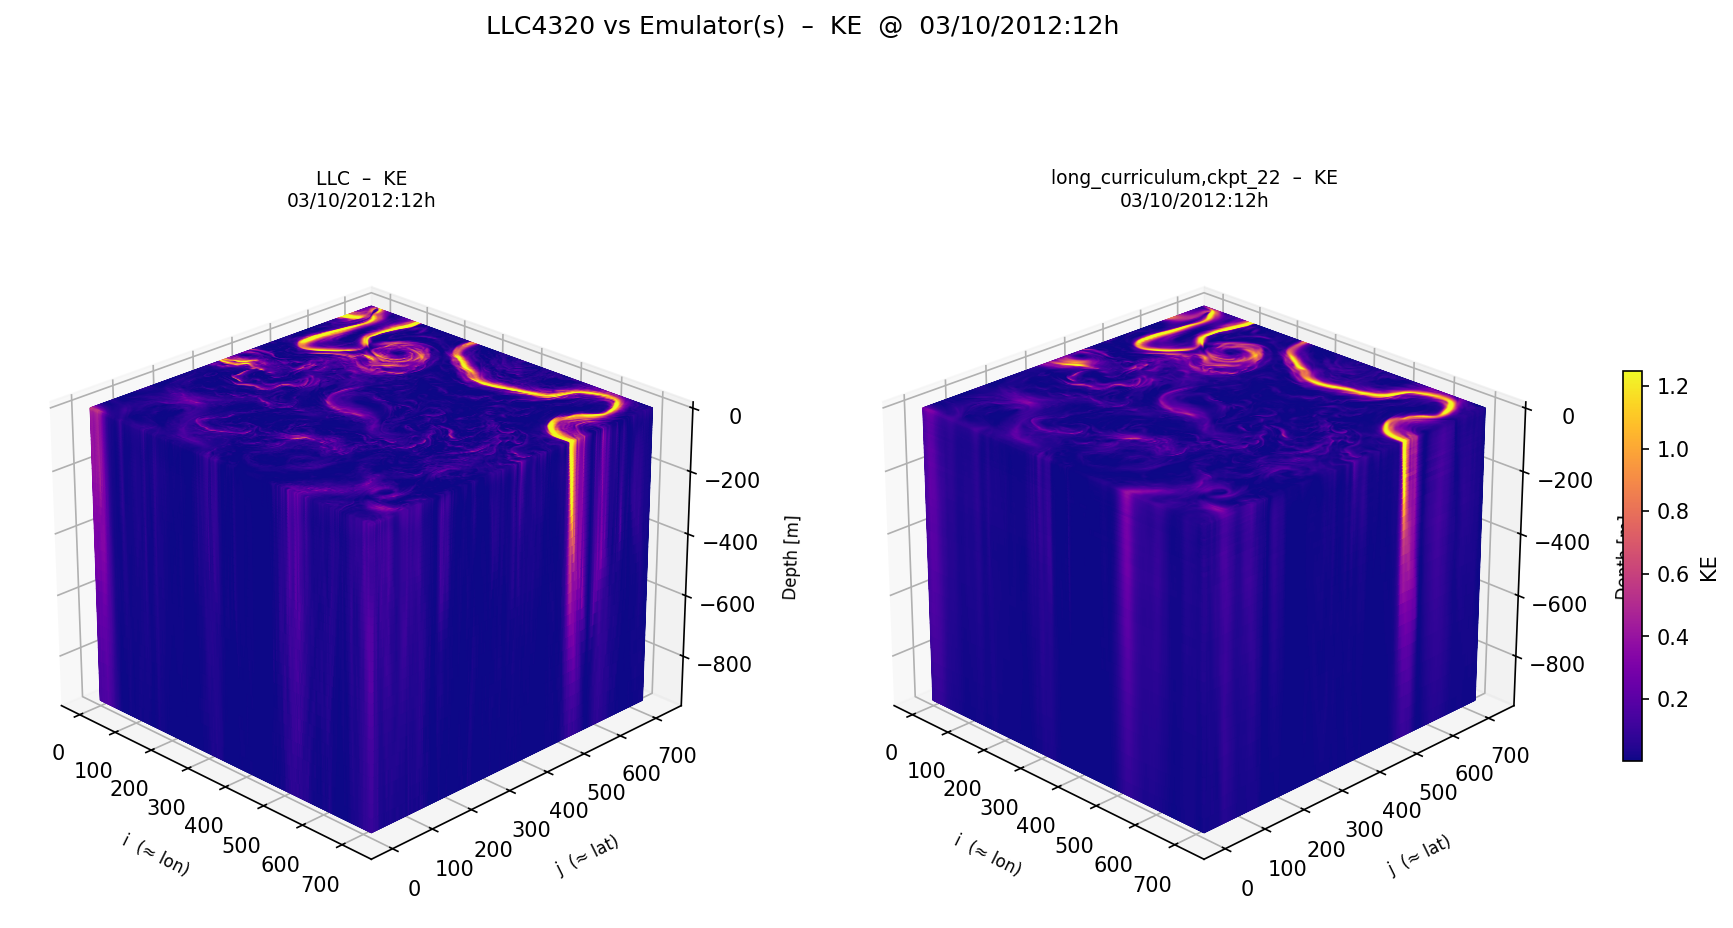

In [ ]:
# ============================================================
#  3-D COMPARISON PLOT  –  LLC vs. Emulator(s)
# ============================================================

# ── USER SETTINGS ────────────────────────────────────────────────────────
plot_time_idx  = 15           # index into the synchronised time axis
plot_vars      = ['KE']   # variables to plot (one figure per variable)
transect_i     = 720         # east-wall i-slice  (surface spans i = 0 … transect_i)
transect_j     = 720         # south-wall j-slice (surface spans j = 0 … transect_j)
k_max          = 51          # depth levels to include  (k = 0 … k_max − 1)
plot_stride    = 1           # horizontal downsampling stride (1 = full-res, slow)
# ─────────────────────────────────────────────────────────────────────────

# ── Colour map ───────────────────────────────────────────────────────────
cmap_3d = plt.cm.plasma # mcolors.LinearSegmentedColormap.from_list(
    # "plasma_dark_3qrt",
    # plt.cm.plasma(np.linspace(0, 0.75, 256)),)

# ── Domain bounds derived from transect selections ───────────────────────
i_0, i_1 = 0, transect_i
j_0, j_1 = 0, transect_j
s = plot_stride

# ── Coordinate arrays ────────────────────────────────────────────────────
i_vals = np.arange(i_0, i_1 + 1)
j_vals = np.arange(j_0, j_1 + 1)

# ── Ordered source list: LLC first, then emulators ───────────────────────
sources = [('LLC', llc_patch)] + [
    (name, emulator_patches[key]) for name, key in emulator_info
]
n_cols = len(sources)

# ── Helper: extract the 3-D block from any patch ─────────────────────────
def _get_block(patch, t_idx, var):
    sub = patch.isel(
        time=t_idx,
        i=slice(i_0, i_1 + 1),
        j=slice(j_0, j_1 + 1),
        k=slice(0, k_max),
    )

    data = sub[var].values      # expected shape: (k, j, i)
    z = sub["Z"].values

    if z.ndim > 1:
        z = z[(slice(None),) + (0,) * (z.ndim - 1)]

    return data, z.ravel()


# ── Helper: return only arrays that are actually plotted ─────────────────
def _get_plotted_faces(var):
    """
    Extract only the values that are sent to plot_surface.

    Returns:
        top surface: var[0, ::s, ::s]
        south wall: var[:, 0, ::s]
        east wall:  var[:, ::s, -1]
    """
    return [
        var[0, ::s, ::s],    # surface face, k = 0
        var[:, 0, ::s],      # south wall, j = 0
        var[:, ::s, -1],     # east wall, i = i_1
    ]


# ── Time label ───────────────────────────────────────────────────────────
time_str = format_time(llc_patch.time.values[plot_time_idx])

# os.makedirs('figs/3d_comparison', exist_ok=True)

# ── One figure per variable ──────────────────────────────────────────────
for plot_var in plot_vars:

    # Pre-fetch all blocks
    blocks = {
        label: _get_block(patch, plot_time_idx, plot_var)
        for label, patch in sources
    }

    # ---------------------------------------------------------------------
    # Colour limits based ONLY on values that are actually plotted:
    #   ① surface face
    #   ② south wall
    #   ③ east wall
    #
    # This excludes the unplotted interior volume.
    # ---------------------------------------------------------------------
    plotted_values = []

    for var, _ in blocks.values():
        for face in _get_plotted_faces(var):
            plotted_values.append(face.ravel())

    plotted_values = np.concatenate(plotted_values)
    plotted_values = plotted_values[np.isfinite(plotted_values)]

    vmin = float(np.nanpercentile(plotted_values, 1))
    vmax = float(np.nanpercentile(plotted_values, 99))

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def to_fc(arr, _n=norm, _c=cmap_3d):
        """Data array → RGBA face-colour array."""
        return _c(_n(arr))

    # ── Figure: 1 row × n_cols subplots ──────────────────────────────────
    fig = plt.figure(figsize=(7 * n_cols, 7), dpi=150)

    for col, (label, _) in enumerate(sources):
        var, z_vals = blocks[label]

        z_top = float(z_vals[0])
        z_bot = float(z_vals[-1])

        ax = fig.add_subplot(1, n_cols, col + 1, projection="3d")

        # ① Surface face  (k = 0) -----------------------------------------
        I_s, J_s = np.meshgrid(i_vals[::s], j_vals[::s])

        ax.plot_surface(
            I_s,
            J_s,
            np.full_like(I_s, z_top, dtype=float),
            facecolors=to_fc(var[0, ::s, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ② South wall  (j = 0) -------------------------------------------
        I_j, Z_j = np.meshgrid(i_vals[::s], z_vals)

        ax.plot_surface(
            I_j,
            np.full_like(I_j, float(j_0)),
            Z_j,
            facecolors=to_fc(var[:, 0, ::s]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ③ East wall  (i = transect_i) -----------------------------------
        J_i, Z_i = np.meshgrid(j_vals[::s], z_vals)

        ax.plot_surface(
            np.full_like(J_i, float(i_1)),
            J_i,
            Z_i,
            facecolors=to_fc(var[:, ::s, -1]),
            shade=False,
            rstride=1,
            cstride=1,
        )

        # ── Box outline edges ─────────────────────────────────────────────
        ek = dict(color="k", linewidth=0.6)

        # Top rectangle
        ax.plot([i_0, i_1], [j_0, j_0], [z_top, z_top], **ek)
        ax.plot([i_0, i_1], [j_1, j_1], [z_top, z_top], **ek)
        ax.plot([i_0, i_0], [j_0, j_1], [z_top, z_top], **ek)
        ax.plot([i_1, i_1], [j_0, j_1], [z_top, z_top], **ek)

        # Bottom edges of the two visible walls
        ax.plot([i_0, i_1], [j_0, j_0], [z_bot, z_bot], **ek)
        ax.plot([i_1, i_1], [j_0, j_1], [z_bot, z_bot], **ek)

        # Vertical edges
        ax.plot([i_0, i_0], [j_0, j_0], [z_top, z_bot], **ek)
        ax.plot([i_1, i_1], [j_0, j_0], [z_top, z_bot], **ek)
        ax.plot([i_1, i_1], [j_1, j_1], [z_top, z_bot], **ek)

        ax.view_init(elev=35, azim=-45)

        ax.set_xlabel("i  (≈ lon)", labelpad=8, fontsize=8)
        ax.set_ylabel("j  (≈ lat)", labelpad=8, fontsize=8)
        ax.set_zlabel("Depth [m]", labelpad=8, fontsize=8)

        ax.set_title(
            f"{label}  –  {plot_var}\n{time_str}",
            fontsize=9,
        )

    # ── Single shared colour bar for all panels ──────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap_3d, norm=norm)
    sm.set_array([])

    cbar_label = "Θ  [°C]" if plot_var == "Theta" else plot_var

    fig.colorbar(
        sm,
        ax=fig.axes,
        fraction=0.012,
        pad=0.05,
        shrink=0.55,
        label=cbar_label,
    )

    plt.suptitle(
        f"LLC4320 vs Emulator(s)  –  {plot_var}  @  {time_str}",
        fontsize=12,
        y=1.02,
    )

    out_path = f"figs/3d_comparison/3d_{plot_var}_{plot_time_idx:03d}.png"

    # plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    # plt.close()
    # print(f"✓  {plot_var}  →  {out_path}")

Computing 3-D gradient drift for Theta …
  LLC  data shape : (51, 720, 720)
  LLC  mask counts: surf=12,960, south=918, east=918


  exp3_ckpt24 mask counts: surf=12,960, south=918, east=918
  Overlap counts: surf=9,229, south=255, east=323


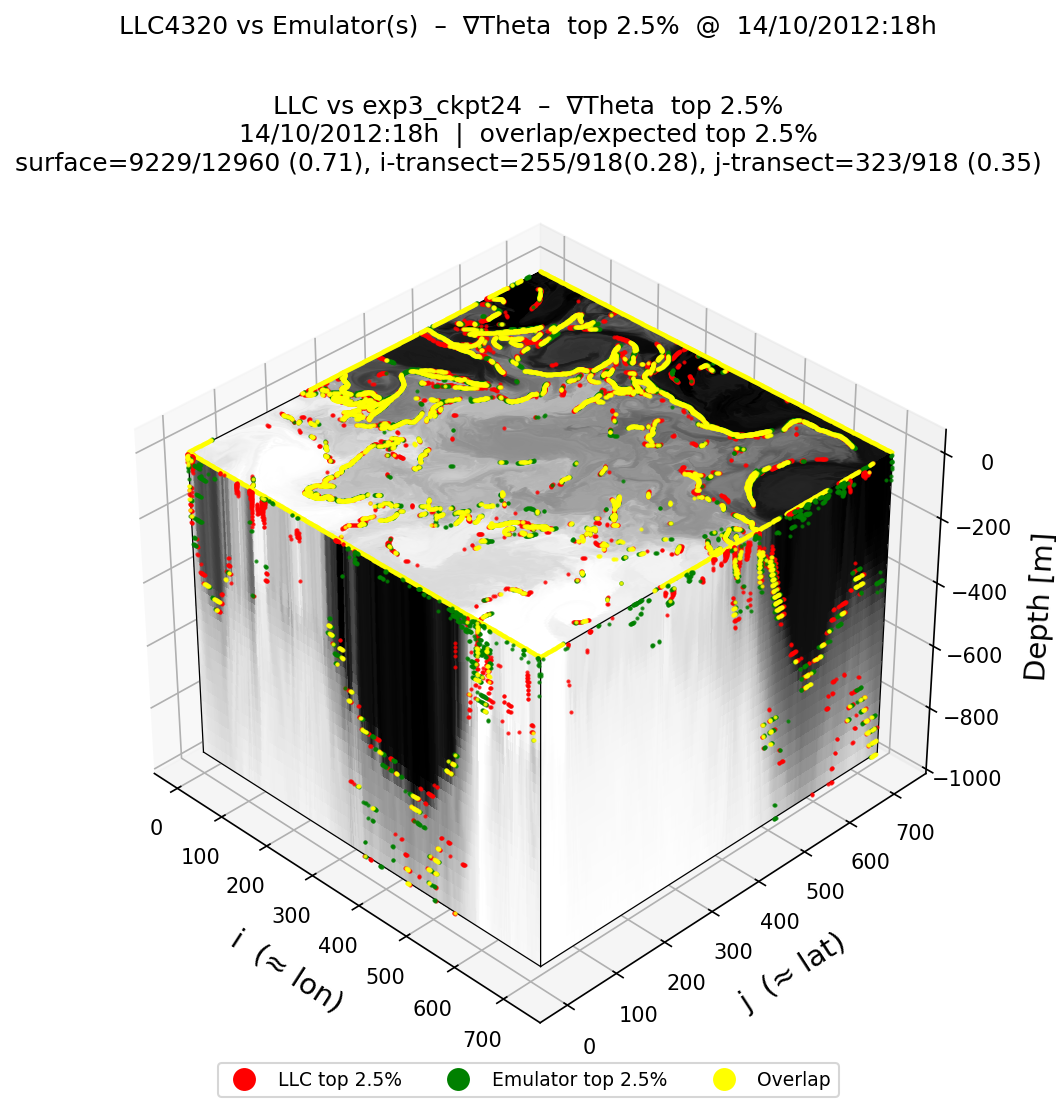

✓  Gradient drift 3-D for Theta


In [5]:
# could make a 3D cube plot that shows surface Theta, side panel 1 could be KE, and side panel 2 could be N2 or vertical gradient or something else???

In [ ]:
# could alos make 3d gradient shift fig and have sides be vertical gradients? how about of KE and T?